# Sentiment EDA -- AFB Instagram

**Scope:** Deep exploratory analysis of comment-level sentiment, joining with:
- `comments_ml.parquet` -- linguistic features
- `pathway_b_assignments_instagram.parquet` -- macro cluster labels *(PROVISIONAL: persona pipeline incomplete -- currently disabled, re-enable later)*
- `Mickey/ig_user_rolling_quadrimesters_new_definitions.csv` -- RFM window-level features
- `ig_multimodal_final.parquet` -- post-level metadata (topic, media type, promo)
- `room_vibe_instagram.parquet` -- post-level aggregated vibe

**Sections:**
1. Data loading & merge
2. Sentiment overview
3. Negative sentiment deep-dive
4. Toxicity analysis
5. Intent & emotion profiling
6. Topic -> sentiment / emotion / toxicity
7. Cluster & RFM lens
8. Linguistic features (comments_ml) vs negativity / toxicity


In [233]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

ROOT = Path('../..')            # AFB_Lab root
ALI  = ROOT / 'Ali' / 'outputs'
MICK = ROOT / 'Mickey'

---
## 1. Data Loading & Merge

In [234]:
# ── core sentiment table ──────────────────────────────────────────────────────
sent = pd.read_parquet(ALI / 'stage2_sentiment' / 'sentiment_instagram.parquet')
print(f'sentiment: {sent.shape}')
sent.dtypes

sentiment: (487604, 33)


comment_id               object
media_id                 object
media_context              bool
sentiment                object
sentiment_score         float64
emotion                  object
intensity                object
sarcasm                    bool
toxicity                 object
intent                   object
target                   object
lang                     object
sentiment_cat            object
sarcasm_label            object
author_id                object
platform                 object
text_length               int64
word_count                int64
emoji_count               int64
unique_emoji_count      float64
emoji_entropy           float64
emoji_variety_ratio     float64
emoji_per_word_ratio    float64
url_count                 int64
mention_count             int64
hashtag_count             int64
exclamation_count         int64
question_count            int64
avg_word_length         float64
has_numbers               int64
has_links                 int64
timestam

In [235]:
# ── comments ML features ──────────────────────────────────────────────────────
cml = pd.read_parquet(ALI / 'comments_ml.parquet')
print(f'comments_ml: {cml.shape}')
cml.dtypes

comments_ml: (3661495, 20)


comment_id               object
author_id                object
media_id                 object
platform                 object
text_length               int64
word_count                int64
emoji_count               int64
unique_emoji_count      float64
emoji_entropy           float64
emoji_variety_ratio     float64
emoji_per_word_ratio    float64
url_count                 int64
mention_count             int64
hashtag_count             int64
exclamation_count         int64
question_count            int64
avg_word_length         float64
has_numbers               int64
has_links                 int64
timestamp                object
dtype: object

In [236]:
# === persona (real): user_personas_combined ==================================
# helper to normalise IG numeric ids that may be stored as float ('123.0') -> '123'
def idstr(s):
    n = pd.to_numeric(s, errors='coerce').round()
    out = n.astype('Int64').astype(str)
    return out.where(out != '<NA>', other=pd.NA)

persona = pd.read_parquet(ALI / 'stage2_persona_combined' / 'user_personas_combined.parquet')
persona['author_id'] = persona['author_id'].astype(str)
print(f'persona: {persona.shape} | codenames: {persona["persona_codename"].nunique()}')
persona['persona_codename'].value_counts()


persona: (40019, 10) | codenames: 10


persona_codename
THE_TAGGER                 11628
THE_CASUAL_COMPLIMENTER     7802
THE_EMOJI_REACTOR           5764
THE_STORYTELLER             4471
THE_SUPERFAN                4191
THE_INQUIRER                2608
THE_CRITIC                  2253
THE_ADVISOR                  865
THE_SPAMMER                  218
THE_HATER                    164
Name: count, dtype: int64

In [237]:
# ── RFM rolling quadrimesters (window-level) ──────────────────────────────────
rfm_path = MICK / 'RFM_IG_rolling_quadrimesters' / 'ig_user_rolling_quadrimesters_new_definitions.csv'
rfm = pd.read_csv(rfm_path)
print(f'RFM windows: {rfm.shape}')
rfm.head(2)

RFM windows: (174287, 18)


,window_id,window_label,window_index,window_start,window_end,window_total_days,posts_in_window,user_key,user_id,username,comment_count,last_comment_timestamp,recency,coverage,engagement,delay,tenure,gini
0,w01,2022-09 to 2022-12,1,2022-09-01,2022-12-31,122,64,1004178702296684,1.004179e+15,dalia_blu,1,2022-11-08 12:55:12,0.421875,0.015625,15.0,1.660833,171.774225,0.0
1,w01,2022-09 to 2022-12,1,2022-09-01,2022-12-31,122,64,1005332278491758,1.005332e+15,__silvigram,2,2022-09-07 10:44:14,0.906250,0.031250,4.0,0.096111,3.747812,0.5


In [238]:
# === post metadata =========================================================
posts = pd.read_parquet(ALI / 'ig_multimodal_final.parquet')
print(f'posts: {posts.shape}')
# media_product_type = FEED / REELS (the 'media' distinction the project cares about);
# media_type = IMAGE / CAROUSEL_ALBUM / VIDEO (asset format)
print('media_product_type:', posts['media_product_type'].value_counts().to_dict())
posts[['media_id','media_product_type','media_type','is_paid_partnership','n_hashtags']].head(3)


posts: (1493, 60)
media_product_type: {'FEED': 1205, 'REELS': 288}


,media_id,media_product_type,media_type,is_paid_partnership,n_hashtags
0,17865483759124019,REELS,VIDEO,False,4.0
1,18454659019005622,REELS,VIDEO,False,0.0
2,18010866632545920,REELS,VIDEO,False,1.0


In [239]:
# ── room vibe (post-level) ────────────────────────────────────────────────────
vibe_path = ALI / 'stage2_sentiment' / 'room_vibe_instagram.parquet'
if not vibe_path.exists():
    vibe_path = ALI / 'room_vibe_instagram.parquet'
vibe = pd.read_parquet(vibe_path)
print(f'room_vibe: {vibe.shape}')
vibe.head(2)

room_vibe: (1501, 22)


,media_id,n_comments,media_context,vibe_score,dispersion,pos_frac,neg_frac,neu_frac,stance_alignment,polarization,...,sarcasm_rate,toxicity_rate,room_state,llm_vibe,dominant_stance,split_axis,room_summary,llm_consensus,llm_alignment,llm_controversy
0,17842069565943166,79,True,0.600000,0.321783,0.835443,0.025316,0.139241,0.886076,0.050633,...,0.012658,0.0,mixed,appreciative,"Overwhelmingly positive, with strong support f...",Artist preference,"The comments are highly positive, expressing s...",0.85,0.8,0.10
1,17842096630720198,93,True,0.453763,0.342527,0.709677,0.021505,0.268817,0.709677,0.043011,...,0.021505,0.0,mixed,appreciative,"Overwhelmingly positive, praising the creator'...",None,"The comments are highly positive, focusing on ...",0.90,0.8,0.05


In [240]:
# -- merge: sentiment <- comments_ml (comment_id) --
ml_cols = [c for c in cml.columns if c not in sent.columns or c == 'comment_id']
df = sent.merge(cml[ml_cols], on='comment_id', how='left')
df['author_id'] = df['author_id'].astype(str)

# -- + persona (author_id) --
persona_cols = ['author_id','persona_codename','confidence',
                'total_comments','activity_span_days','reply_ratio','mean_word_count']
persona_cols = [c for c in persona_cols if c in persona.columns]
df = df.merge(persona[persona_cols], on='author_id', how='left', suffixes=('','_persona'))

# -- + post meta (media_id) -- media_product_type = FEED/REELS --
post_cols = ['media_id','media_product_type','media_type','is_paid_partnership',
             'n_hashtags','n_mentions','comments_count','like_count',
             'has_audio','video_duration','caption']
post_cols = [c for c in post_cols if c in posts.columns]
df = df.merge(posts[post_cols], on='media_id', how='left', suffixes=('','_post'))

# -- + room_vibe (media_id) --
vibe_cols = ['media_id','vibe_score','toxicity_rate','controversy','room_state','llm_vibe']
vibe_cols = [c for c in vibe_cols if c in vibe.columns]
df = df.merge(vibe[vibe_cols], on='media_id', how='left', suffixes=('','_room'))

print(f'merged df: {df.shape}')
print(f'persona coverage: {df["persona_codename"].notna().mean():.1%}')
df.head(2)


merged df: (487604, 54)
persona coverage: 19.3%


,comment_id,media_id,media_context,sentiment,sentiment_score,emotion,intensity,sarcasm,toxicity,intent,...,comments_count,like_count,has_audio,video_duration,caption,vibe_score,toxicity_rate,controversy,room_state,llm_vibe
0,ig_comment_17845323725457819,17878142638896365,True,positive,0.6,joy,medium,False,none,praise,...,746.0,222627.0,None,NaN,Tra la prima e la seconda foto sono passati di...,0.656319,0.001374,0.049737,united,appreciative
1,ig_comment_17881671244864415,17878142638896365,True,positive,0.8,joy,high,False,none,praise,...,746.0,222627.0,None,NaN,Tra la prima e la seconda foto sono passati di...,0.656319,0.001374,0.049737,united,appreciative


In [241]:
# === RFM: most recent window per user =======================================
rfm_latest = (
    rfm.sort_values('window_end', ascending=False)
       .drop_duplicates('user_id')
       [['user_id','window_label','recency','coverage','engagement','delay','tenure','gini']]
       .rename(columns={'user_id': 'author_id'})
)
# user_id is float64 (e.g. 1004178702296684.0) -> clean integer string to match author_id
rfm_latest['author_id'] = idstr(rfm_latest['author_id'])
df = df.merge(rfm_latest, on='author_id', how='left')
print(f'RFM coverage: {df["recency"].notna().mean():.1%}')

# === Mickey named clusters (user-level, k=4 KMeans on RCEDTG) ================
mick_clusters = pd.read_csv(
    MICK / 'RFM_IG_rolling_quadrimesters' / 'Ig_RCEDTG_kmeans_k4_user_clusters.csv',
    usecols=['user_id','cluster','cluster_name']
).rename(columns={'user_id': 'author_id', 'cluster': 'rfm_cluster', 'cluster_name': 'rfm_cluster_name'})
mick_clusters['author_id'] = idstr(mick_clusters['author_id'])
df = df.merge(mick_clusters, on='author_id', how='left')

print(f'Mickey RFM cluster coverage: {df["rfm_cluster_name"].notna().mean():.1%}')
print(df['rfm_cluster_name'].value_counts())


RFM coverage: 32.1%
Mickey RFM cluster coverage: 32.0%
rfm_cluster_name
Passive regulars        50602
Established regulars    41714
Occasional Visitors     39981
Brand advocates         23628
Name: count, dtype: int64


In [242]:
# === derived flags =========================================================
df['is_negative'] = df['sentiment'].str.lower().isin(['negative','neg'])

# toxicity column is ORDINAL: none / mild / severe  (not a boolean)
df['tox_severity'] = (df['toxicity'].astype(str).str.lower().str.strip()
                        .where(lambda s: s.isin(['none','mild','severe']), 'none'))
df['is_toxic'] = df['tox_severity'].isin(['mild','severe'])

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.day_name()
df['month']     = df['timestamp'].dt.to_period('M').astype(str)

print('Sentiment value counts:')
print(df['sentiment'].value_counts())
print()
print('Toxicity severity counts:')
print(df['tox_severity'].value_counts())
print()
print('is_toxic (mild+severe): {:,} ({:.2%})'.format(df['is_toxic'].sum(), df['is_toxic'].mean()))


Sentiment value counts:
sentiment
positive    394276
neutral      68737
negative     24591
Name: count, dtype: int64

Toxicity severity counts:
tox_severity
none      484523
mild        2752
severe       329
Name: count, dtype: int64

is_toxic (mild+severe): 3,081 (0.63%)


---
## 2. Sentiment Overview

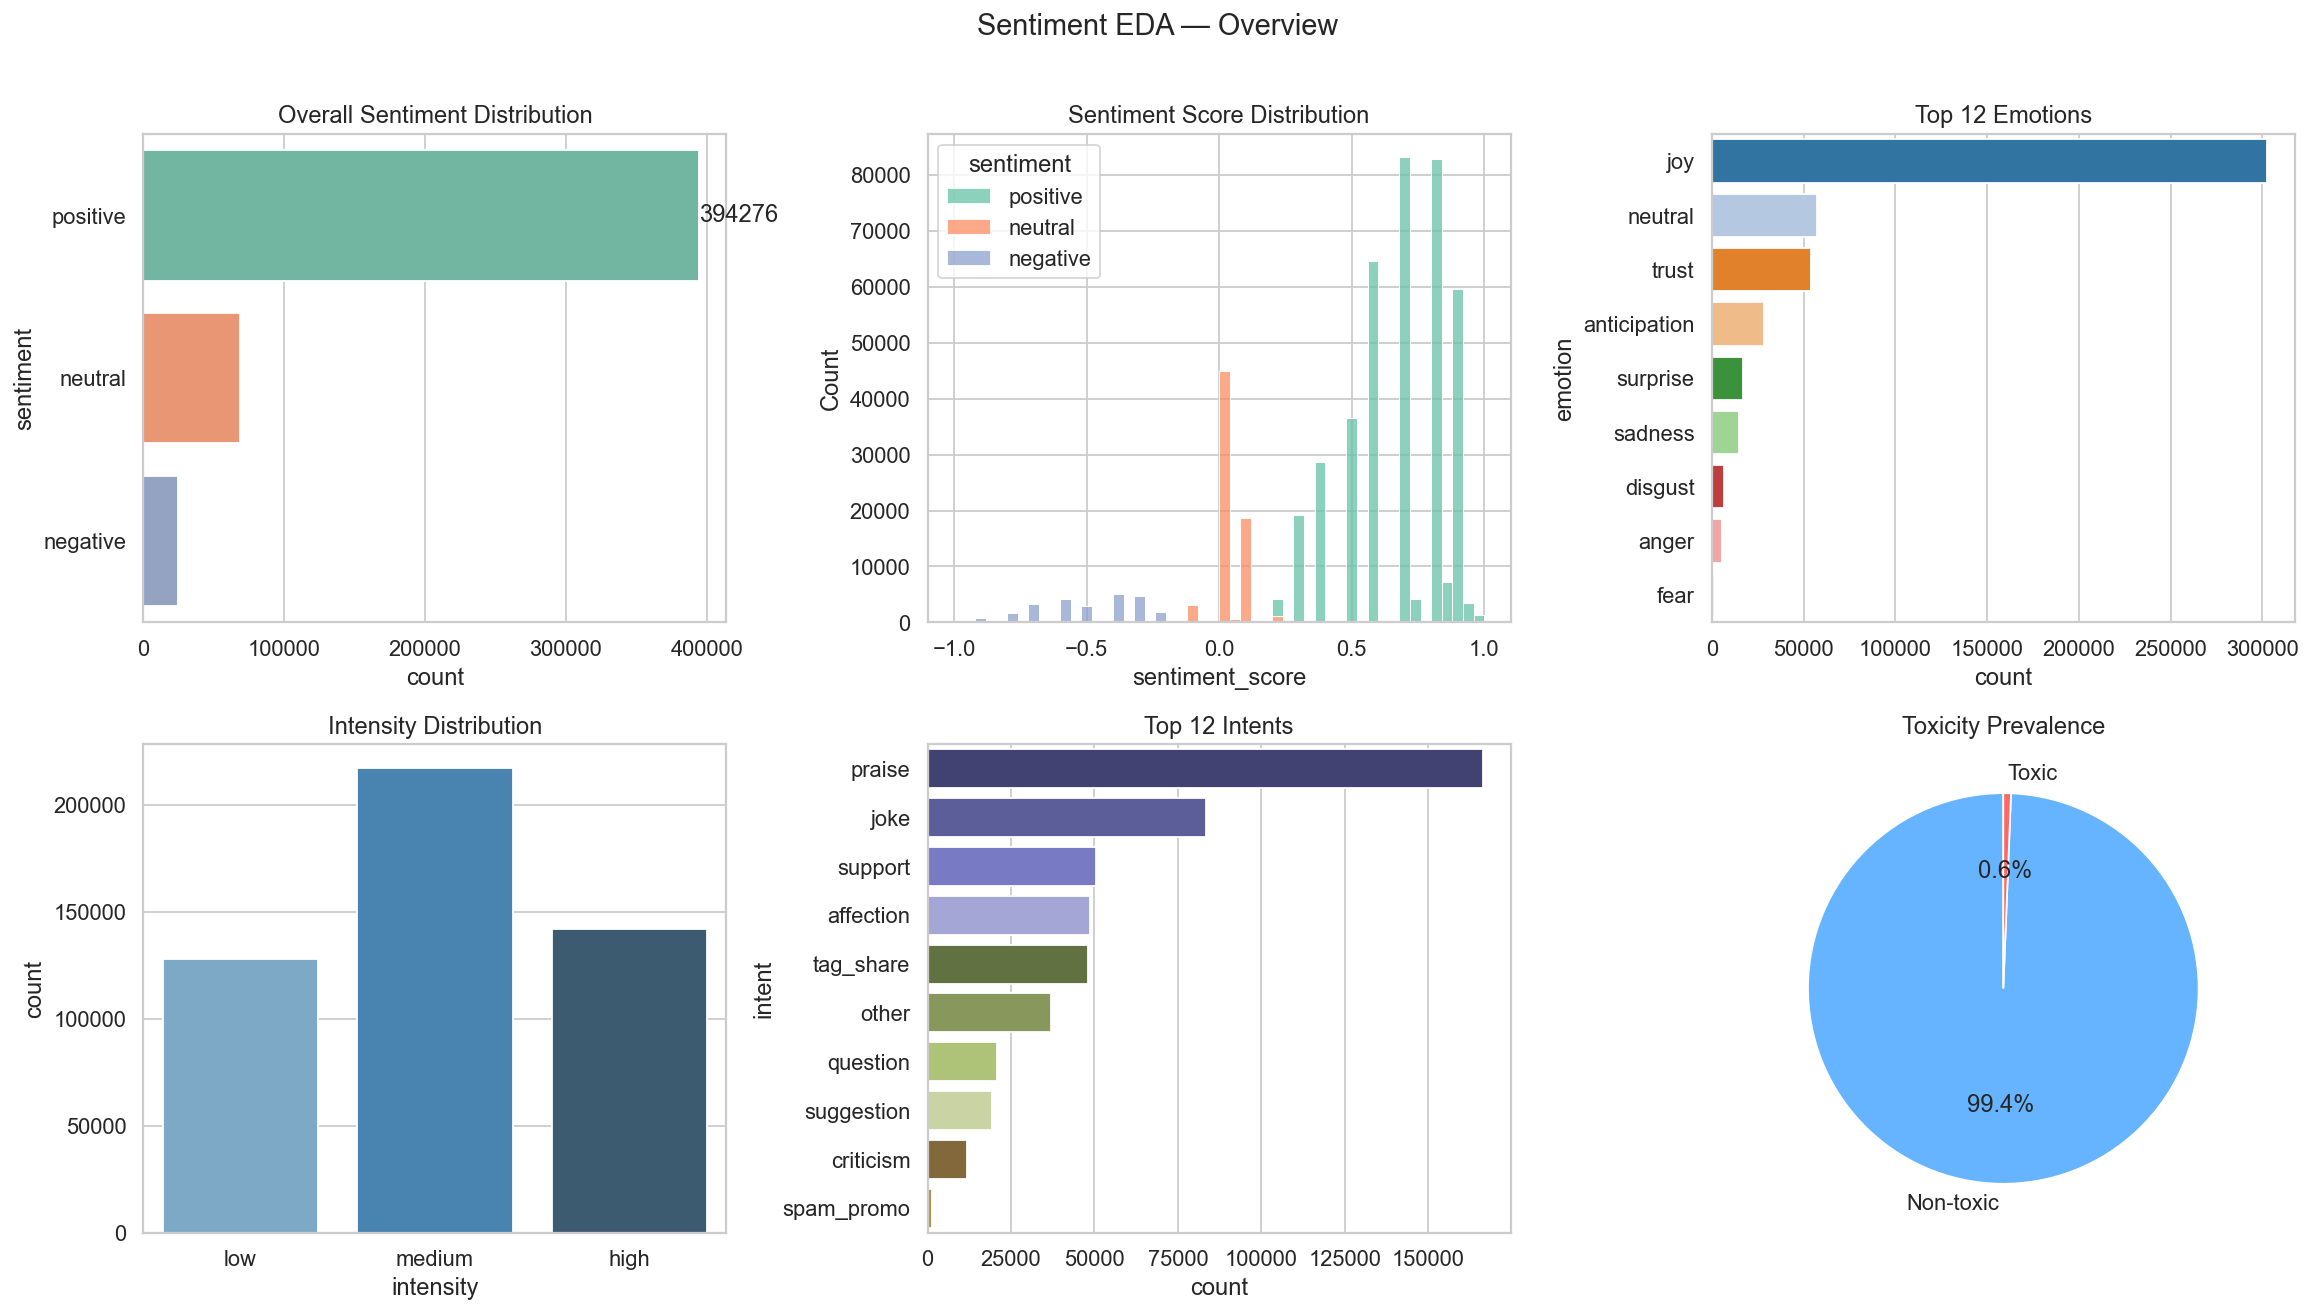

In [243]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2.1 Sentiment distribution
ax = axes[0, 0]
order = df['sentiment'].value_counts().index
sns.countplot(data=df, y='sentiment', order=order, ax=ax, palette='Set2')
ax.set_title('Overall Sentiment Distribution')
ax.bar_label(ax.containers[0], fmt='%d')

# 2.2 Sentiment score distribution
ax = axes[0, 1]
sns.histplot(data=df, x='sentiment_score', hue='sentiment', bins=50,
             multiple='stack', ax=ax, palette='Set2')
ax.set_title('Sentiment Score Distribution')

# 2.3 Emotion distribution
ax = axes[0, 2]
em_order = df['emotion'].value_counts().head(12).index
sns.countplot(data=df, y='emotion', order=em_order, ax=ax, palette='tab20')
ax.set_title('Top 12 Emotions')

# 2.4 Intensity distribution
ax = axes[1, 0]
sns.countplot(data=df, x='intensity', order=['low','medium','high'], ax=ax, palette='Blues_d')
ax.set_title('Intensity Distribution')

# 2.5 Intent distribution
ax = axes[1, 1]
intent_order = df['intent'].value_counts().head(12).index
sns.countplot(data=df, y='intent', order=intent_order, ax=ax, palette='tab20b')
ax.set_title('Top 12 Intents')

# 2.6 Toxicity rate
ax = axes[1, 2]
tox_counts = df['is_toxic'].value_counts()
_lab = {False: 'Non-toxic', True: 'Toxic'}
_pie_labels = [_lab.get(k, str(k)) for k in tox_counts.index]
_pie_colors = ['#66b3ff' if not k else '#ff6666' for k in tox_counts.index]
ax.pie(tox_counts.values, labels=_pie_labels, autopct='%1.1f%%',
       colors=_pie_colors, startangle=90)
ax.set_title('Toxicity Prevalence')

plt.suptitle('Sentiment EDA — Overview', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(OUT / '01_sentiment_overview.png', dpi=300)
plt.savefig(OUT / '01_sentiment_overview.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

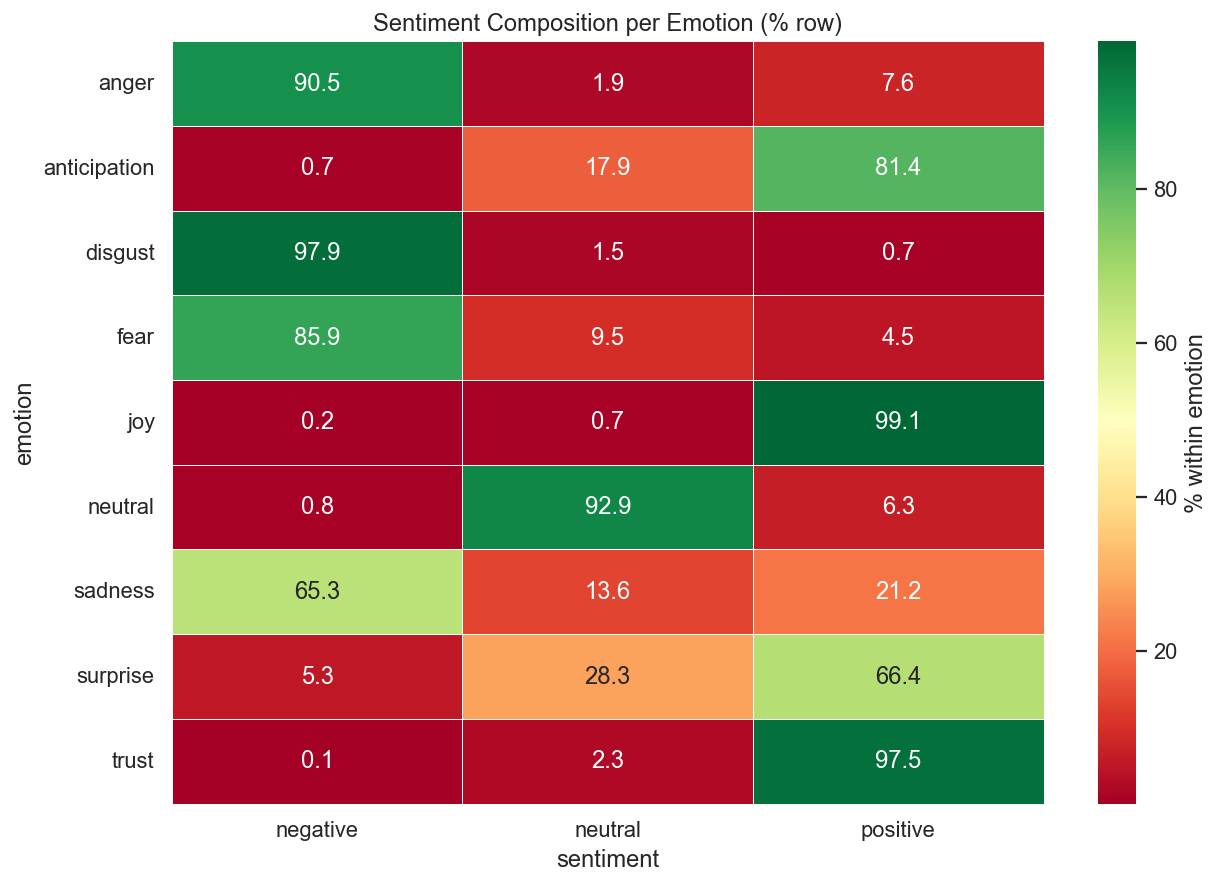

In [244]:
# Sentiment x Emotion heatmap
top_emotions = df['emotion'].value_counts().head(14).index
_mask_em = df['emotion'].isin(top_emotions)
ct = pd.crosstab(
    df.loc[_mask_em, 'emotion'],
    df.loc[_mask_em, 'sentiment'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=.5, cbar_kws={'label': '% within emotion'})
ax.set_title('Sentiment Composition per Emotion (% row)')
plt.tight_layout()
plt.savefig(OUT / '02_emotion_sentiment_heatmap.png', dpi=300)
plt.savefig(OUT / '02_emotion_sentiment_heatmap.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


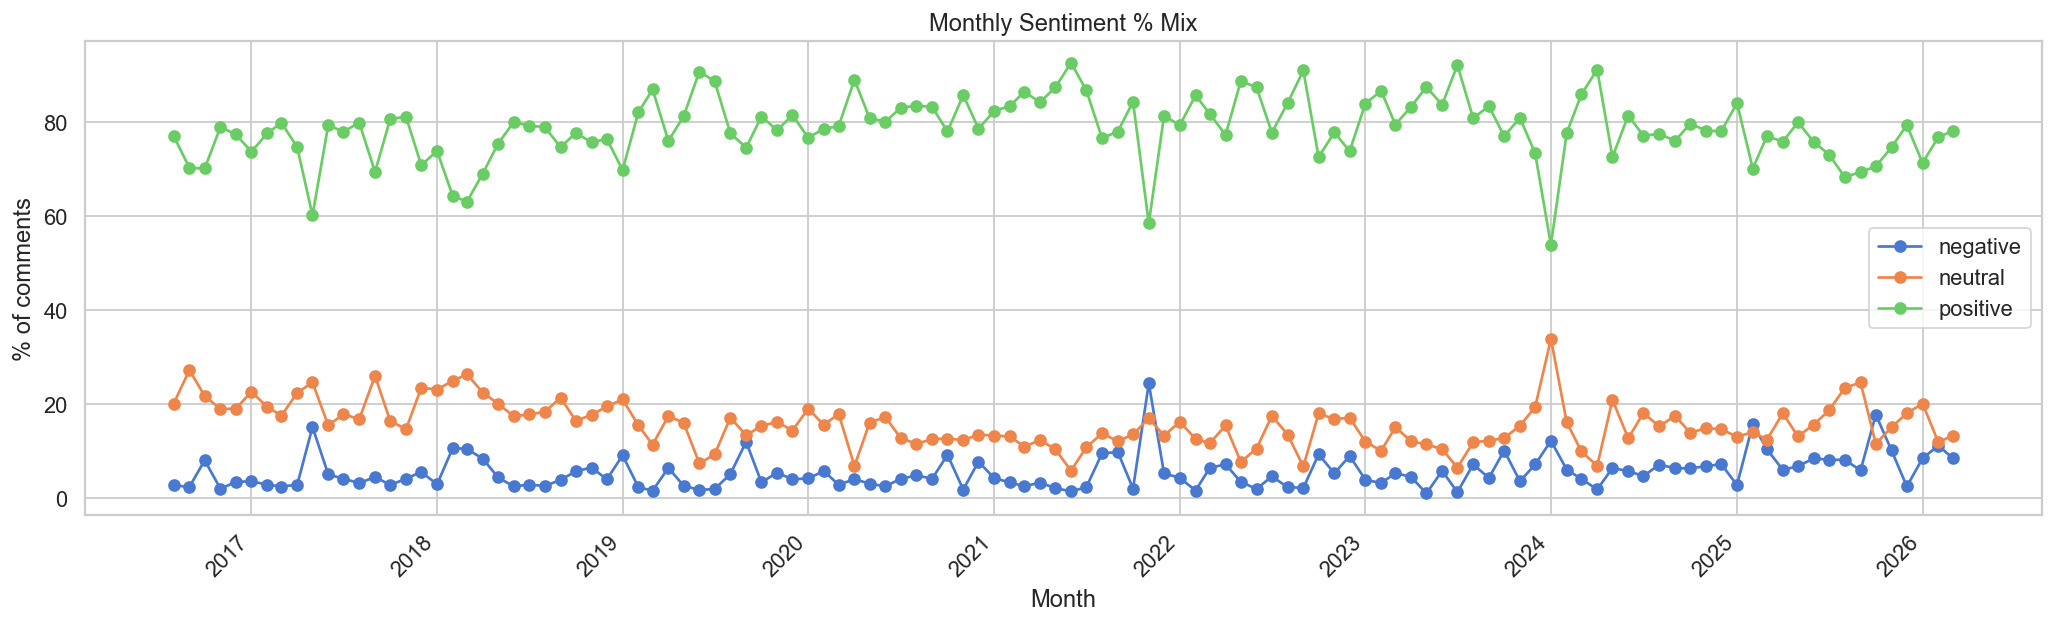

In [245]:
# Sentiment trend over time (monthly)
monthly = (
    df.groupby(['month','sentiment'])
      .size()
      .reset_index(name='n')
)
monthly_pct = monthly.copy()
monthly_pct['pct'] = monthly_pct.groupby('month')['n'].transform(lambda x: x / x.sum() * 100)
# cast to str explicitly to guard against matplotlib UnitData objects in the column
monthly_pct['month_dt'] = pd.to_datetime(monthly_pct['month'].astype(str), format='%Y-%m', errors='coerce')

fig, ax = plt.subplots(figsize=(16, 5))
for s, grp in monthly_pct.groupby('sentiment'):
    ax.plot(grp['month_dt'].values, grp['pct'], marker='o', label=s)
ax.set_title('Monthly Sentiment % Mix')
ax.set_xlabel('Month')
ax.set_ylabel('% of comments')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')
plt.tight_layout()
plt.savefig(OUT / '03_sentiment_monthly_trend.png', dpi=300)
plt.savefig(OUT / '03_sentiment_monthly_trend.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


---
## 3. Negative Sentiment Deep-Dive

Negative comments: 24,591 (5.0% of total)


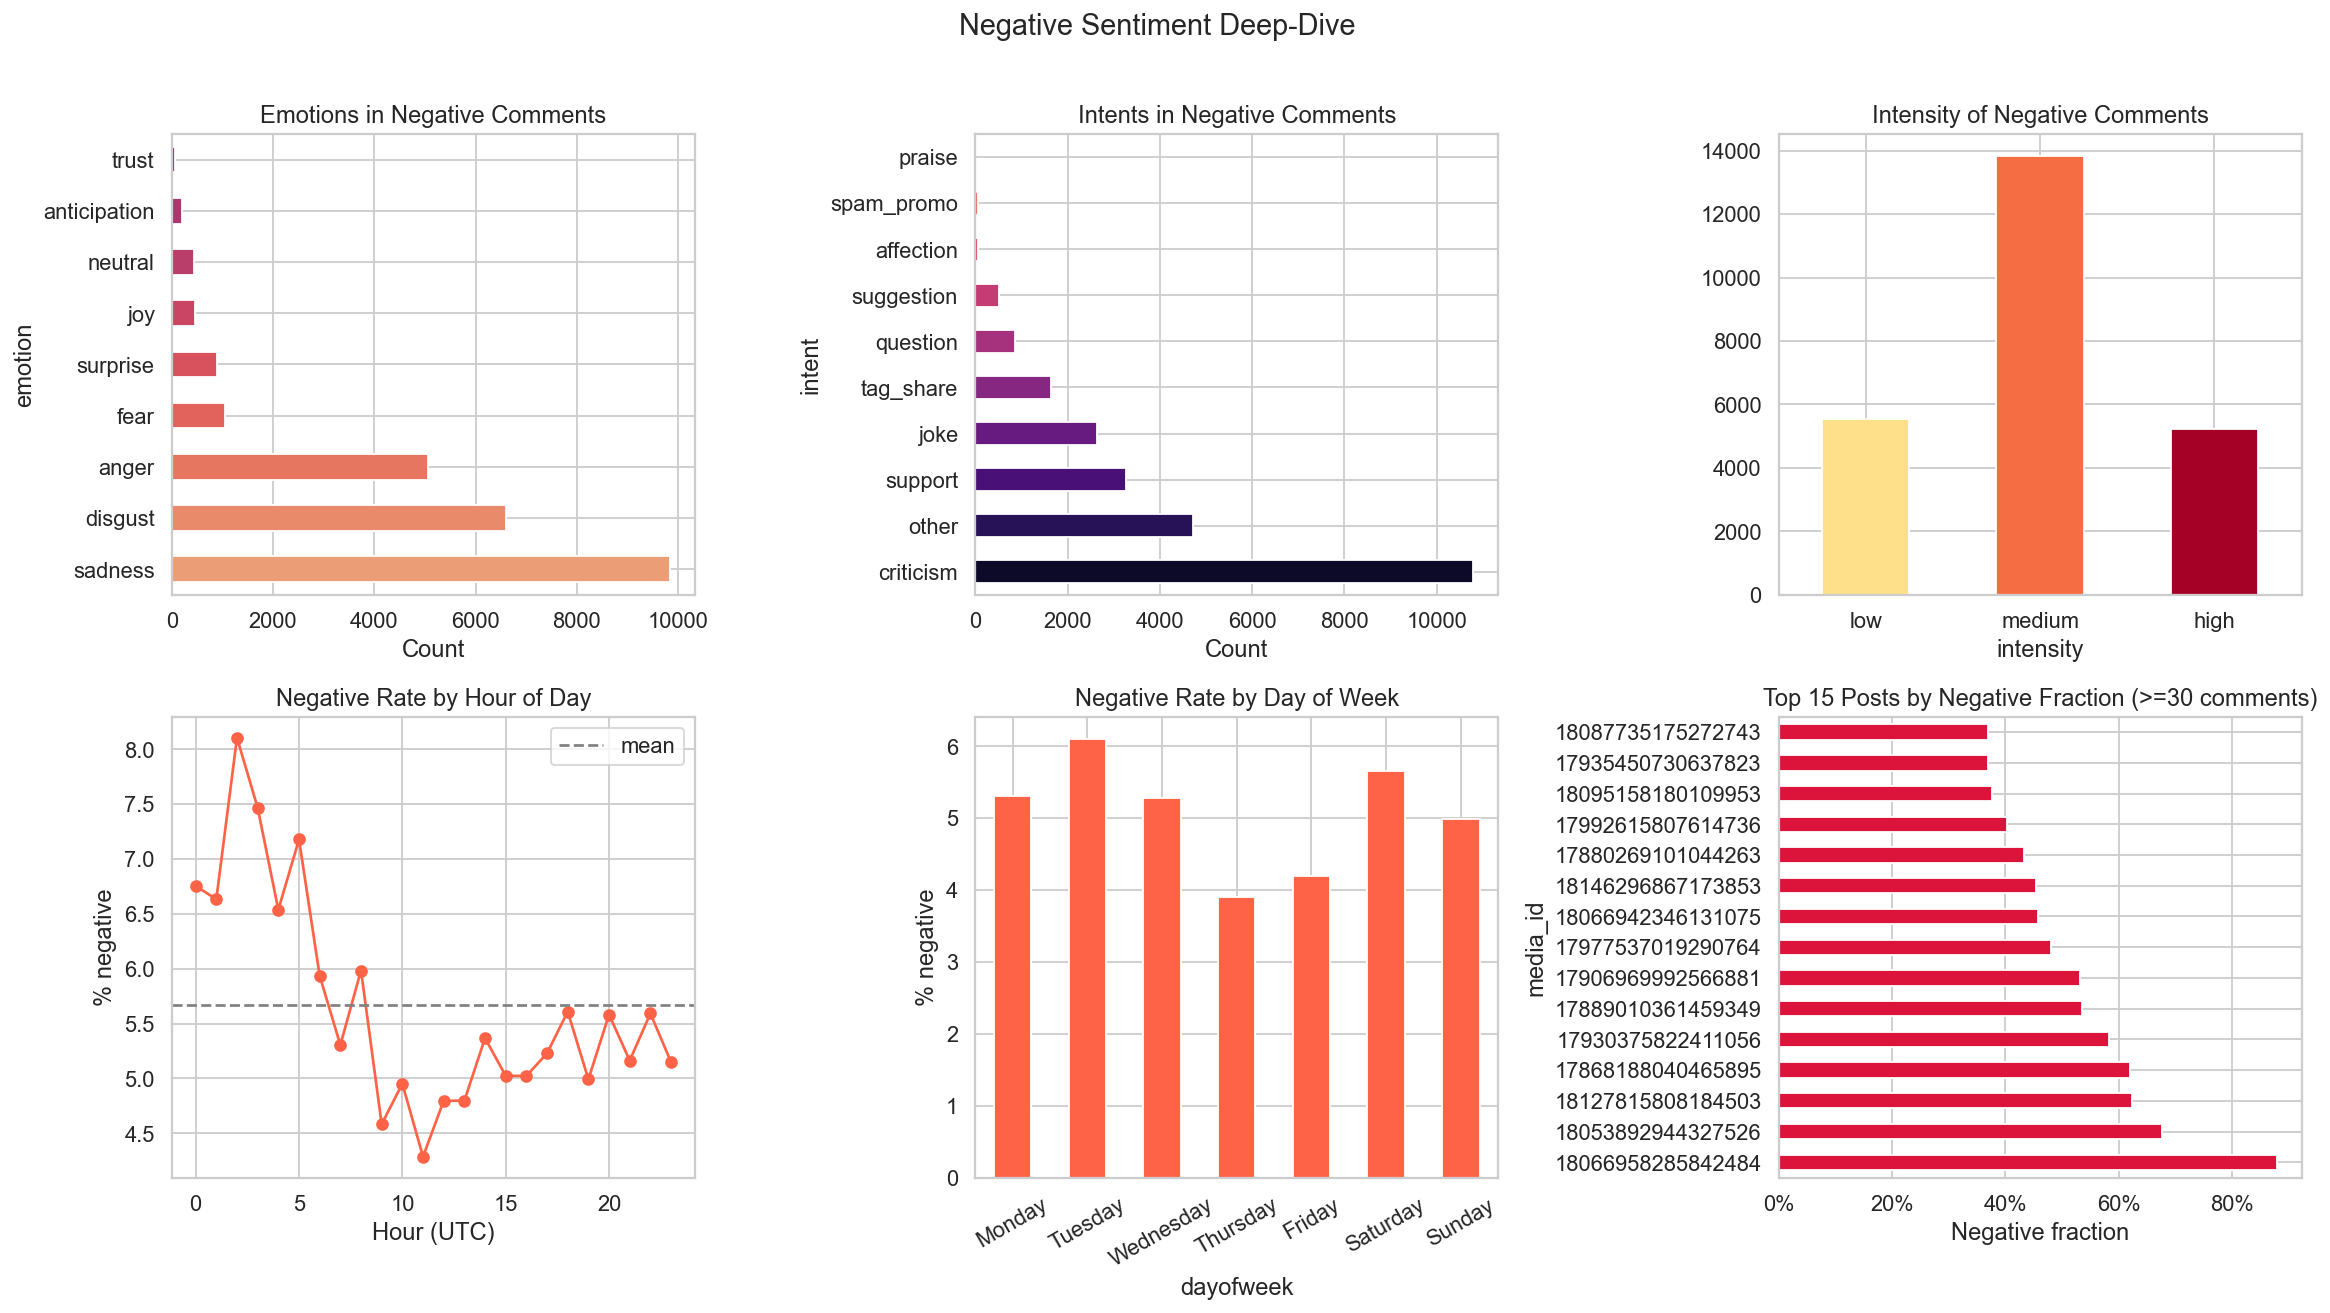

In [246]:
_mask_neg = df['is_negative']
_neg_cols = ['emotion', 'intent', 'intensity']
neg = df.loc[_mask_neg, _neg_cols]
print(f'Negative comments: {_mask_neg.sum():,} ({_mask_neg.mean():.1%} of total)')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 3.1 Emotion within negative
ax = axes[0, 0]
em_neg = neg['emotion'].value_counts().head(12)
em_neg.plot.barh(ax=ax, color=sns.color_palette('flare', 12))
ax.set_title('Emotions in Negative Comments')
ax.set_xlabel('Count')

# 3.2 Intent within negative
ax = axes[0, 1]
int_neg = neg['intent'].value_counts().head(12)
int_neg.plot.barh(ax=ax, color=sns.color_palette('magma', 12))
ax.set_title('Intents in Negative Comments')
ax.set_xlabel('Count')

# 3.3 Intensity within negative
ax = axes[0, 2]
int_levels = neg['intensity'].value_counts().reindex(['low', 'medium', 'high'])
int_levels.plot.bar(ax=ax, color=['#fee08b', '#f46d43', '#a50026'], rot=0)
ax.set_title('Intensity of Negative Comments')

# 3.4 Negative rate by hour
ax = axes[1, 0]
hourly_neg = df.groupby('hour')['is_negative'].mean() * 100
ax.plot(hourly_neg.index, hourly_neg.values, marker='o', color='tomato')
ax.set_title('Negative Rate by Hour of Day')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('% negative')
ax.axhline(hourly_neg.mean(), ls='--', color='grey', label='mean')
ax.legend()

# 3.5 Negative rate by day of week
ax = axes[1, 1]
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_neg = df.groupby('dayofweek')['is_negative'].mean().reindex(dow_order) * 100
dow_neg.plot.bar(ax=ax, color='tomato', rot=30)
ax.set_title('Negative Rate by Day of Week')
ax.set_ylabel('% negative')

# 3.6 Posts with highest negative fraction
ax = axes[1, 2]
post_neg = (
    df.groupby('media_id')
      .agg(n_total=('comment_id', 'count'), n_neg=('is_negative', 'sum'))
      .assign(neg_frac=lambda x: x['n_neg'] / x['n_total'])
      .query('n_total >= 30')
      .nlargest(15, 'neg_frac')
)
post_neg['neg_frac'].plot.barh(ax=ax, color='crimson')
ax.set_title('Top 15 Posts by Negative Fraction (>=30 comments)')
ax.set_xlabel('Negative fraction')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Negative Sentiment Deep-Dive', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(OUT / '04_negative_deepdive.png', dpi=300)
plt.savefig(OUT / '04_negative_deepdive.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


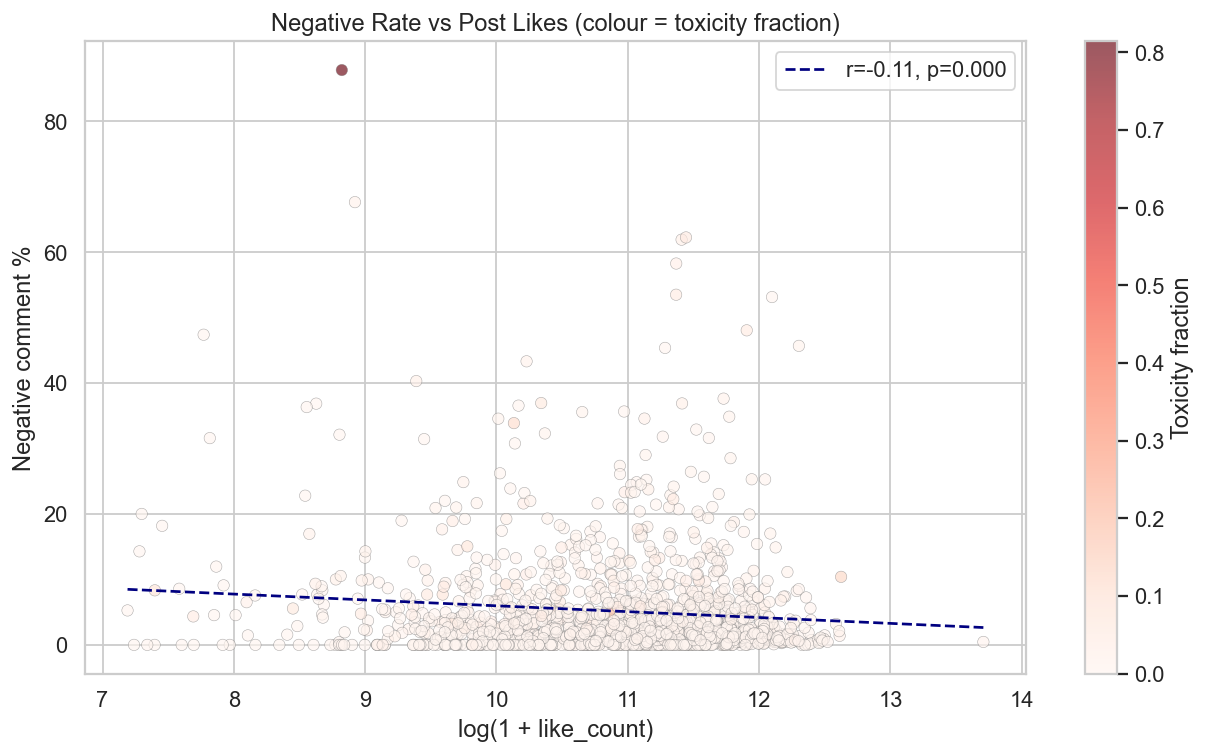

In [247]:
# Negative rate per post vs engagement
post_stats = (
    df.groupby('media_id')
      .agg(n_total=('comment_id','count'),
           n_neg=('is_negative','sum'),
           n_toxic=('is_toxic','sum'),
           like_count=('like_count','first'),
           comments_count=('comments_count','first'),
           media_type=('media_type','first'),
           is_paid=('is_paid_partnership','first'))
      .assign(neg_frac=lambda x: x['n_neg'] / x['n_total'],
              tox_frac=lambda x: x['n_toxic'] / x['n_total'])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    np.log1p(post_stats['like_count']),
    post_stats['neg_frac'] * 100,
    c=post_stats['tox_frac'],
    cmap='Reds', alpha=0.65, s=40, edgecolors='grey', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Toxicity fraction')
ax.set_xlabel('log(1 + like_count)')
ax.set_ylabel('Negative comment %')
ax.set_title('Negative Rate vs Post Likes (colour = toxicity fraction)')
# regression
mask = post_stats[['like_count','neg_frac']].notna().all(axis=1)
x = np.log1p(post_stats.loc[mask,'like_count'])
y = post_stats.loc[mask,'neg_frac'] * 100
m, b, r, p, _ = stats.linregress(x, y)
ax.plot(x.sort_values(), m * x.sort_values() + b, color='navy', lw=1.5, ls='--',
        label=f'r={r:.2f}, p={p:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / '05_neg_vs_likes.png', dpi=300)
plt.savefig(OUT / '05_neg_vs_likes.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

In [248]:
# Top negative users (prolific commenters with high negative rate)
user_neg = (
    df.groupby('author_id')
      .agg(total=('comment_id','count'), neg_n=('is_negative','sum'))
      .assign(neg_rate=lambda x: x['neg_n'] / x['total'])
      .query('total >= 10')
      .nlargest(20, 'neg_n')
)
print('Top 20 users by volume of negative comments (≥10 total comments):')
print(user_neg.to_string())

Top 20 users by volume of negative comments (≥10 total comments):
                   total  neg_n  neg_rate
author_id                                
17841401147950242  21064    963  0.045718
None                1152     69  0.059896
1593117128649999     176     46  0.261364
1548495633951246     450     33  0.073333
4024468751177060     217     20  0.092166
941320635502920      213     20  0.093897
1432199375258086      40     19  0.475000
1709182523581619     284     14  0.049296
2854109358266851     244     14  0.057377
1474319521068741      16     13  0.812500
4223750531211935      52     13  0.250000
908266745384508      257     13  0.050584
908868895388503       13     13  1.000000
1480010030308478      25     12  0.480000
1525392635832436     114     12  0.105263
2232648670477249      97     12  0.123711
34389191084062788     41     12  0.292683
907506032254526      343     12  0.034985
1242033407634806     120     11  0.091667
26244447005221632     54     11  0.203704


---
## 4. Toxicity Analysis

Toxic comments: 3,081 (0.63%)


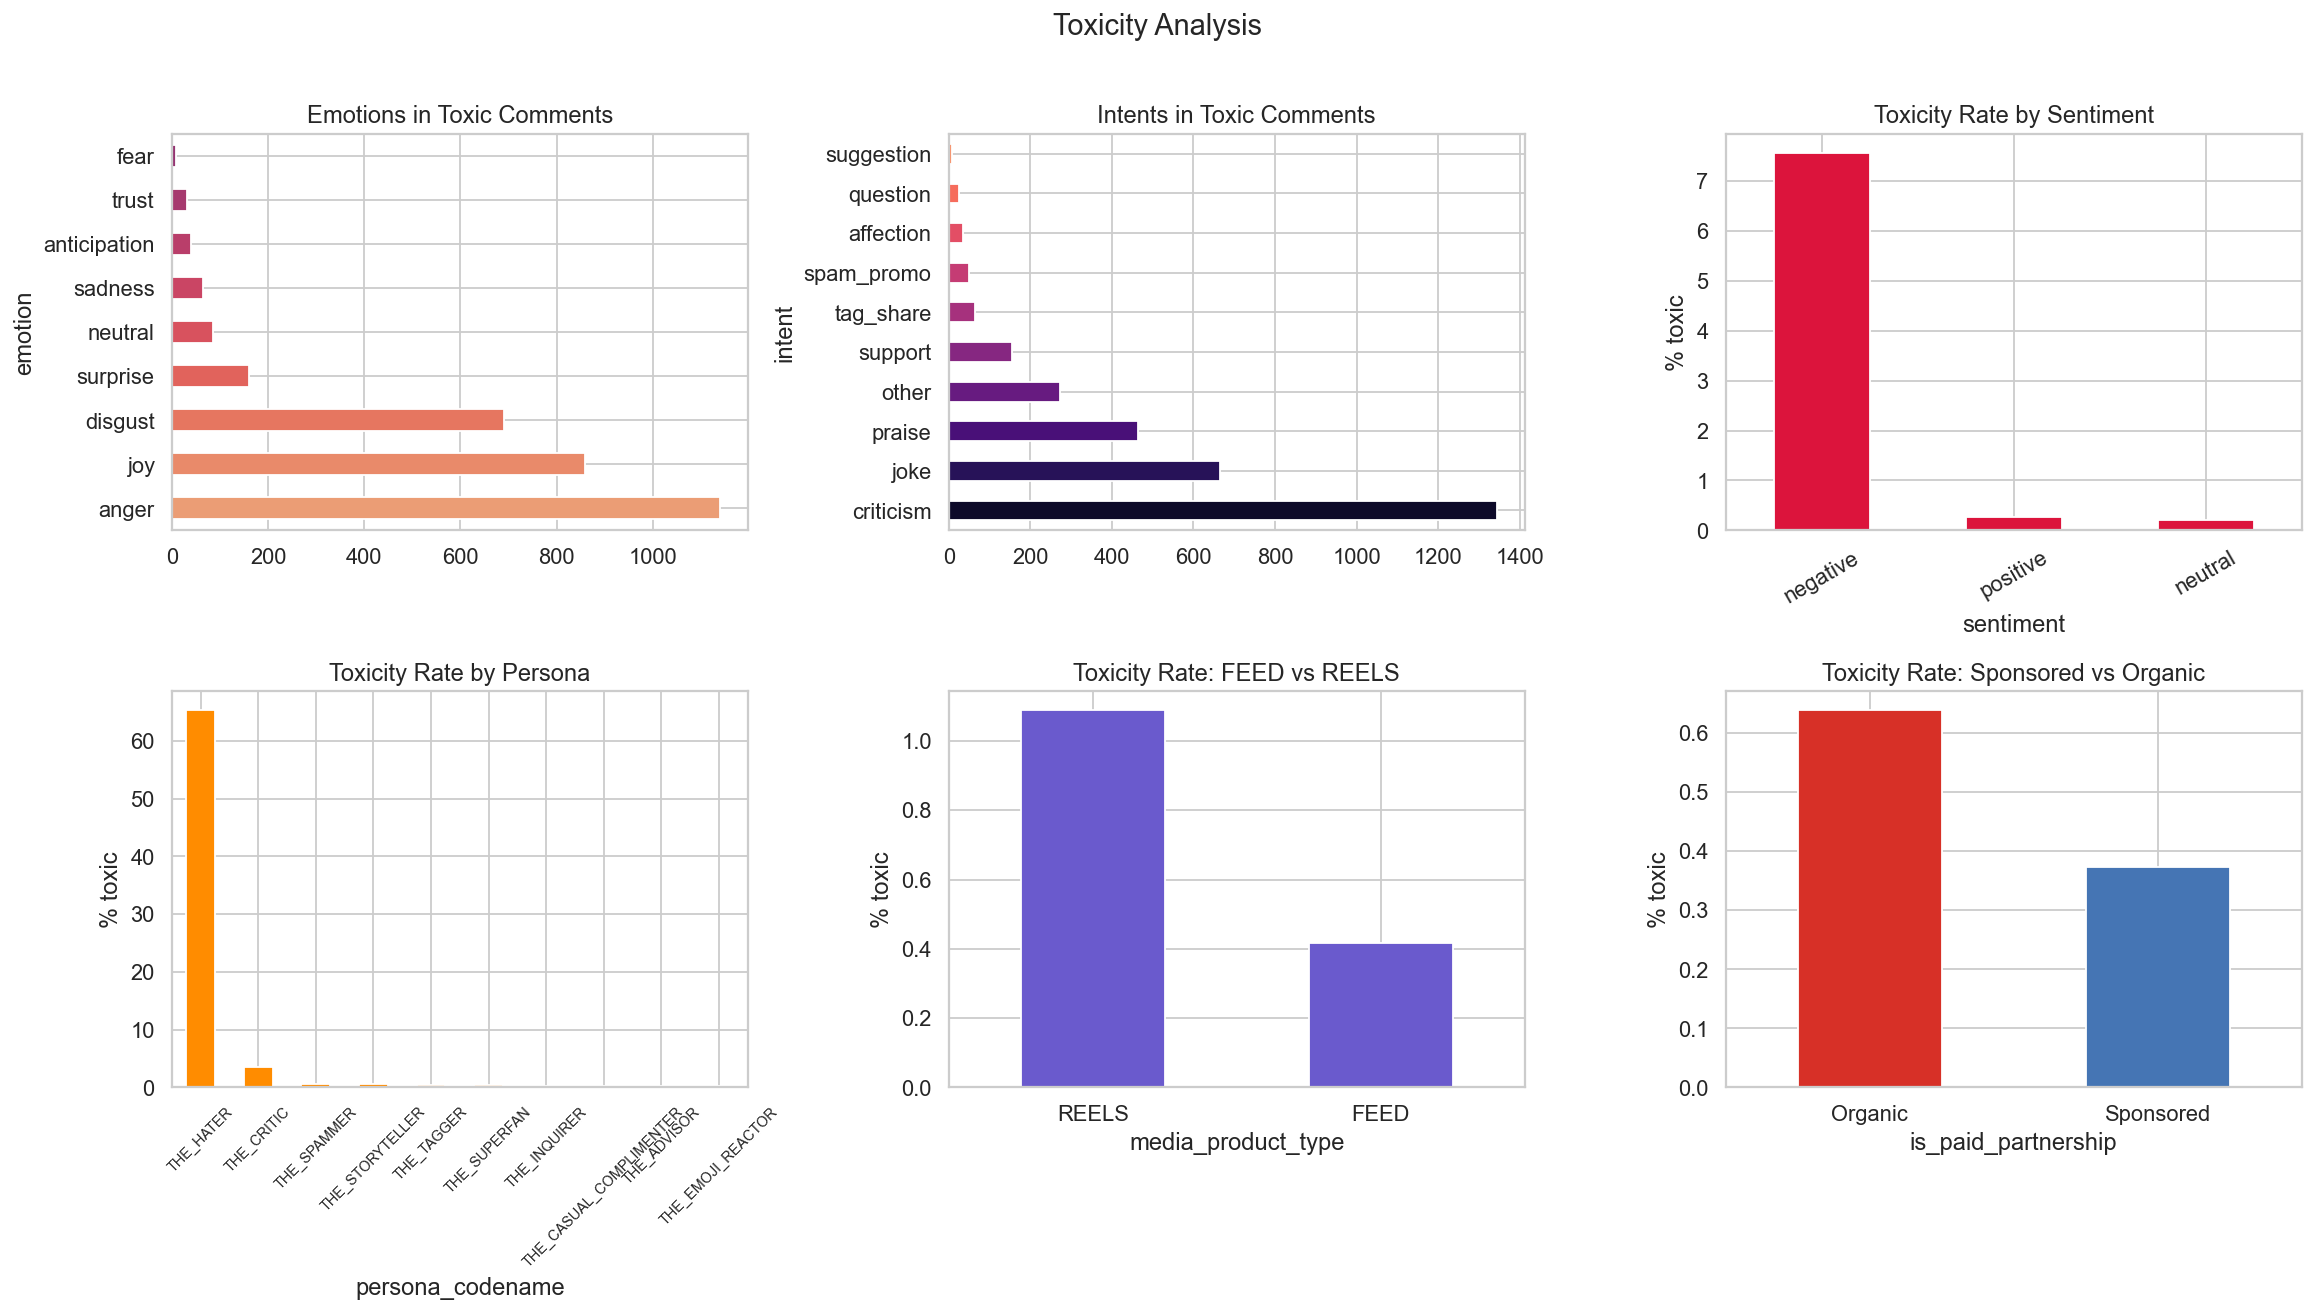

In [249]:
_mask_tox = df['is_toxic']
_tox_cols = ['emotion', 'intent']
tox = df.loc[_mask_tox, _tox_cols]
print(f'Toxic comments: {_mask_tox.sum():,} ({_mask_tox.mean():.2%})')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 4.1 Toxic emotion distribution
ax = axes[0, 0]
tox['emotion'].value_counts().head(12).plot.barh(ax=ax, color=sns.color_palette('flare', 12))
ax.set_title('Emotions in Toxic Comments')

# 4.2 Toxic intent distribution
ax = axes[0, 1]
tox['intent'].value_counts().head(12).plot.barh(ax=ax, color=sns.color_palette('magma', 12))
ax.set_title('Intents in Toxic Comments')

# 4.3 Toxicity rate by sentiment
ax = axes[0, 2]
tox_by_sent = df.groupby('sentiment')['is_toxic'].mean() * 100
tox_by_sent.sort_values(ascending=False).plot.bar(ax=ax, color='crimson', rot=30)
ax.set_title('Toxicity Rate by Sentiment')
ax.set_ylabel('% toxic')

# 4.4 Toxicity rate by persona codename
ax = axes[1, 0]
if df['persona_codename'].notna().any():
    tox_by_persona = (df.dropna(subset=['persona_codename'])
                        .groupby('persona_codename')['is_toxic'].mean()
                        .sort_values(ascending=False) * 100)
    tox_by_persona.plot.bar(ax=ax, color='darkorange', rot=45)
    ax.set_title('Toxicity Rate by Persona')
    ax.set_ylabel('% toxic')
    ax.tick_params(axis='x', labelsize=8)

# 4.5 Toxicity rate by media_product_type (FEED / REELS)
ax = axes[1, 1]
if 'media_product_type' in df.columns:
    tox_by_media = df.groupby('media_product_type')['is_toxic'].mean().sort_values(ascending=False) * 100
    tox_by_media.plot.bar(ax=ax, color='slateblue', rot=0)
    ax.set_title('Toxicity Rate: FEED vs REELS')
    ax.set_ylabel('% toxic')

# 4.6 Toxicity rate by paid partnership
ax = axes[1, 2]
if 'is_paid_partnership' in df.columns:
    tox_by_paid = df.groupby('is_paid_partnership')['is_toxic'].mean() * 100
    tox_by_paid.index = tox_by_paid.index.map({True: 'Sponsored', False: 'Organic', 1: 'Sponsored', 0: 'Organic'})
    tox_by_paid.plot.bar(ax=ax, color=['#d73027', '#4575b4'], rot=0)
    ax.set_title('Toxicity Rate: Sponsored vs Organic')
    ax.set_ylabel('% toxic')

plt.suptitle('Toxicity Analysis', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(OUT / '06_toxicity_analysis.png'    , dpi=300)
plt.savefig(OUT / '06_toxicity_analysis.svg'    , dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


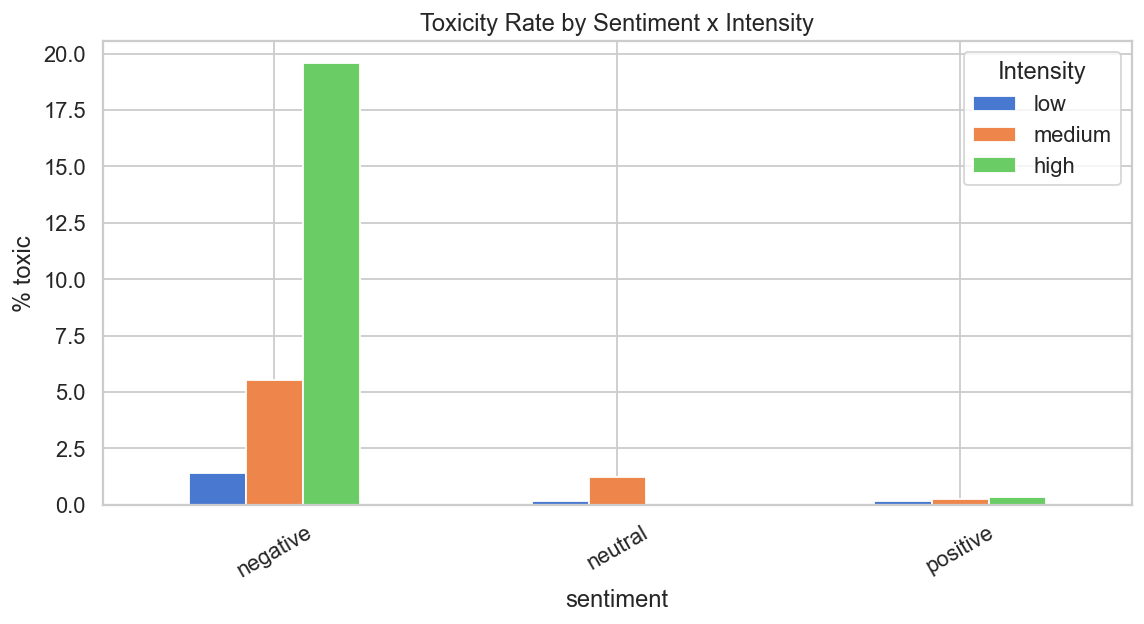

In [250]:
# Toxicity rate by Sentiment x Intensity
tox_rate = (
    df.groupby(['sentiment','intensity'])['is_toxic']
      .mean().mul(100)
      .unstack('intensity')
)
# order intensity columns if the usual labels are present
intensity_order = [c for c in ['low','medium','high'] if c in tox_rate.columns]
if intensity_order:
    tox_rate = tox_rate[intensity_order + [c for c in tox_rate.columns if c not in intensity_order]]

fig, ax = plt.subplots(figsize=(9, 5))
tox_rate.plot.bar(ax=ax, rot=30)
ax.set_title('Toxicity Rate by Sentiment x Intensity')
ax.set_ylabel('% toxic')
ax.legend(title='Intensity')
plt.tight_layout()
plt.savefig(OUT / '07_toxicity_sent_intensity.png', dpi=300)
plt.savefig(OUT / '07_toxicity_sent_intensity.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


In [251]:
# Most toxic posts
toxic_posts = (
    post_stats.query('n_total >= 20')
              .nlargest(15, 'tox_frac')
              [['media_id','n_total','n_neg','n_toxic','neg_frac','tox_frac','media_type','is_paid']]
)
print('Top 15 most toxic posts (≥20 comments):')
print(toxic_posts.to_string(index=False))

Top 15 most toxic posts (≥20 comments):
         media_id  n_total  n_neg  n_toxic  neg_frac  tox_frac     media_type is_paid
18066958285842484      172    151      140  0.877907  0.813953          VIDEO   False
18012853979580282      139      7       26  0.050360  0.187050 CAROUSEL_ALBUM   False
18141280402343532     2608    271      339  0.103911  0.129985          VIDEO   False
18061973351108959       62     21        7  0.338710  0.112903 CAROUSEL_ALBUM   False
17964638207786355       37      2        3  0.054054  0.081081 CAROUSEL_ALBUM   False
17867492983092443       39      3        3  0.076923  0.076923          IMAGE   False
17889610462003617       54      5        4  0.092593  0.074074          IMAGE   False
18082563064995703      206     31       15  0.150485  0.072816          VIDEO   False
17856068767170027      181      8       13  0.044199  0.071823          IMAGE   False
17878373251042325       31      1        2  0.032258  0.064516          IMAGE   False
17966039671101

---
## 5. Intent & Emotion Profiling

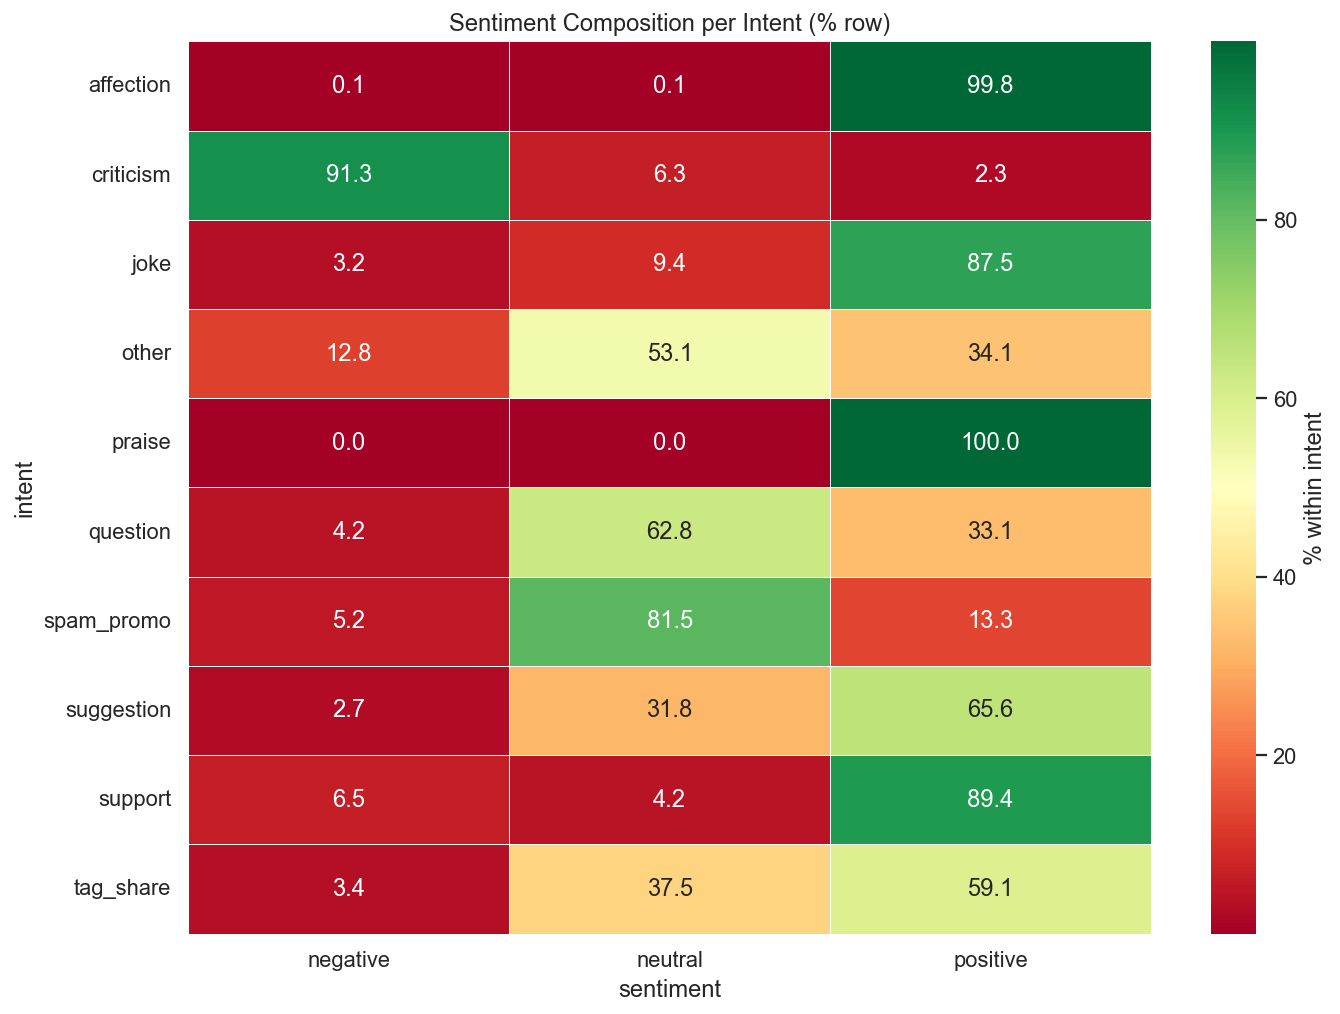

In [252]:
# Intent x Sentiment heatmap (% within intent)
top_intents = df['intent'].value_counts().head(14).index
_mask_in = df['intent'].isin(top_intents)
ct_intent = pd.crosstab(
    df.loc[_mask_in, 'intent'],
    df.loc[_mask_in, 'sentiment'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(ct_intent, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=.5, cbar_kws={'label': '% within intent'})
ax.set_title('Sentiment Composition per Intent (% row)')
plt.tight_layout()
plt.savefig(OUT / '08_intent_sentiment_heatmap.png', dpi=300)
plt.savefig(OUT / '08_intent_sentiment_heatmap.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


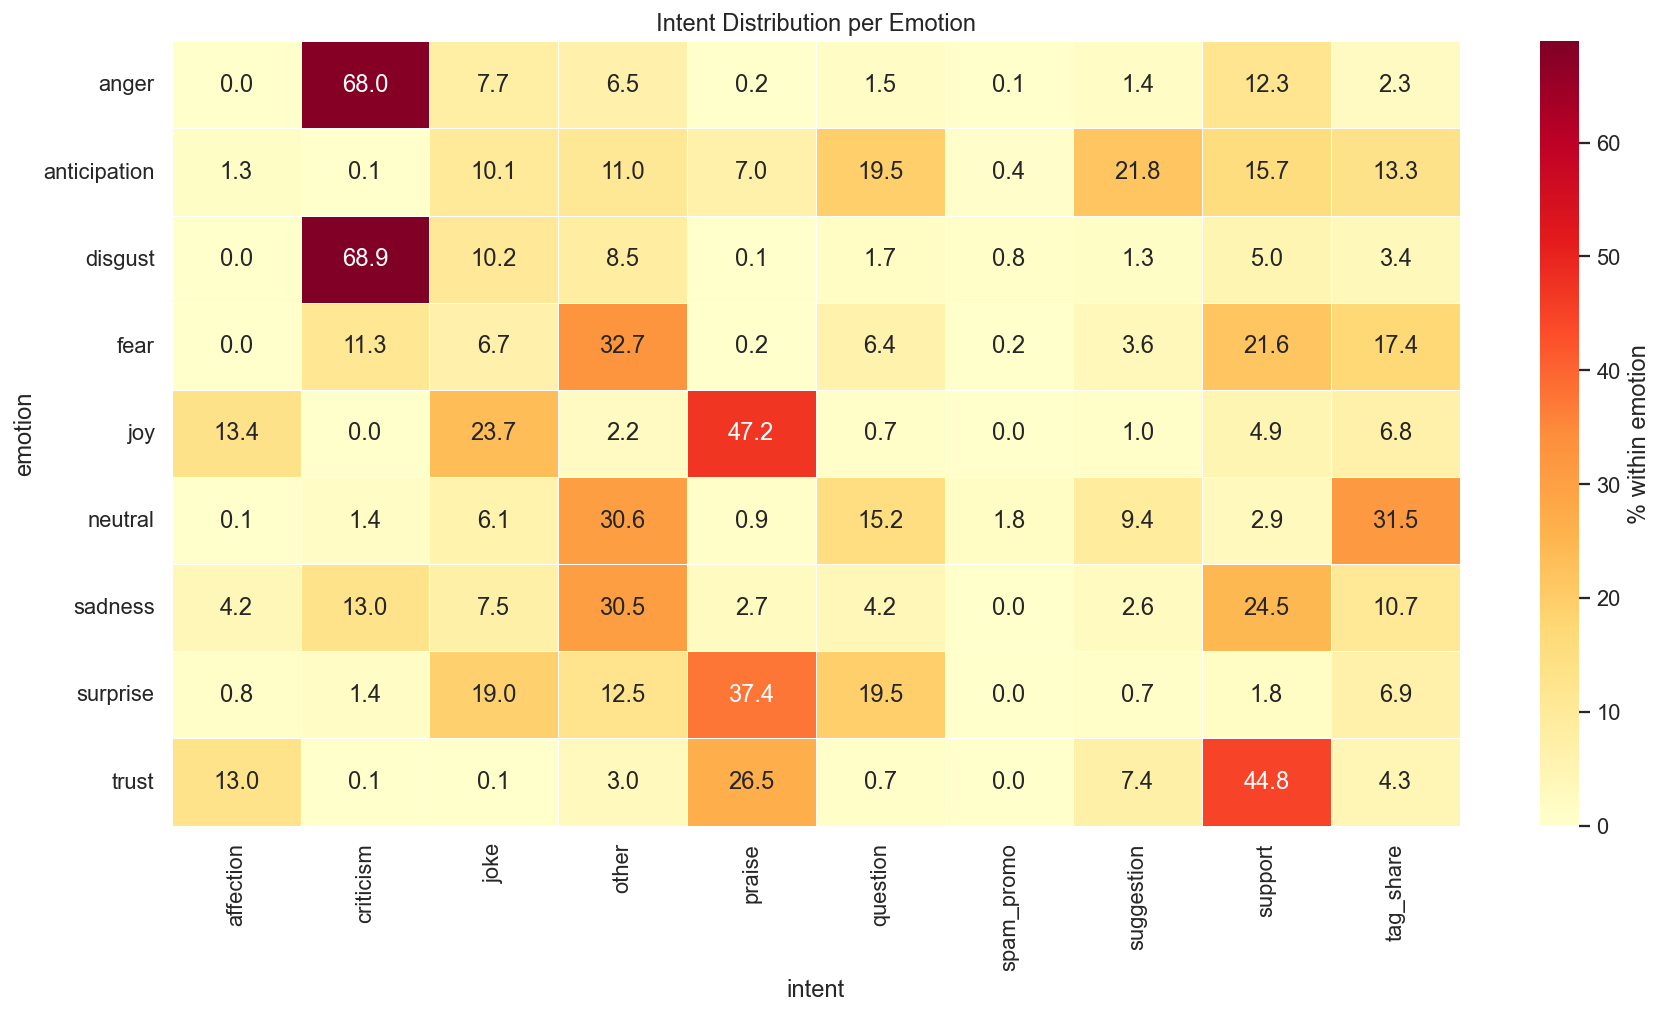

In [253]:
# Emotion x Intent heatmap (co-occurrence)
top_em = df['emotion'].value_counts().head(12).index
top_in = df['intent'].value_counts().head(12).index
_mask_ei = df['emotion'].isin(top_em) & df['intent'].isin(top_in)
ct_ei = pd.crosstab(
    df.loc[_mask_ei, 'emotion'],
    df.loc[_mask_ei, 'intent'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct_ei, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=.5, cbar_kws={'label': '% within emotion'})
ax.set_title('Intent Distribution per Emotion')
plt.tight_layout()
plt.savefig(OUT / '09_emotion_intent_heatmap.png', dpi=300)
plt.savefig(OUT / '09_emotion_intent_heatmap.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()


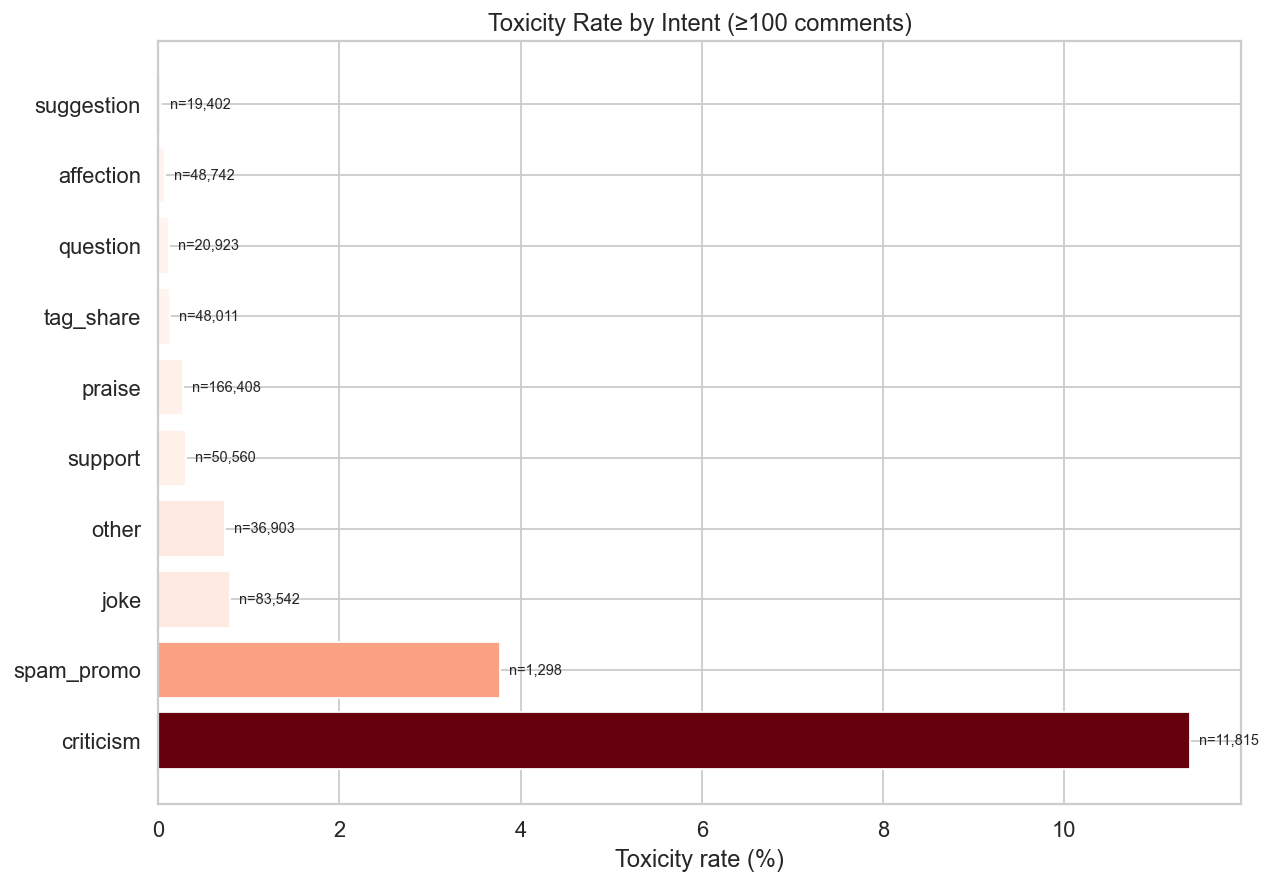

In [254]:
# Toxicity rate per intent — ranked
intent_tox = (
    df.groupby('intent')
      .agg(n=('comment_id','count'), tox_n=('is_toxic','sum'))
      .assign(tox_rate=lambda x: x['tox_n'] / x['n'] * 100)
      .query('n >= 100')
      .sort_values('tox_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(intent_tox.index, intent_tox['tox_rate'],
               color=plt.cm.Reds(intent_tox['tox_rate'] / intent_tox['tox_rate'].max()))
ax.set_xlabel('Toxicity rate (%)')
ax.set_title('Toxicity Rate by Intent (≥100 comments)')
for bar, n in zip(bars, intent_tox['n']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'n={n:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT / '10_toxicity_by_intent.png', dpi=300)
plt.savefig(OUT / '10_toxicity_by_intent.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

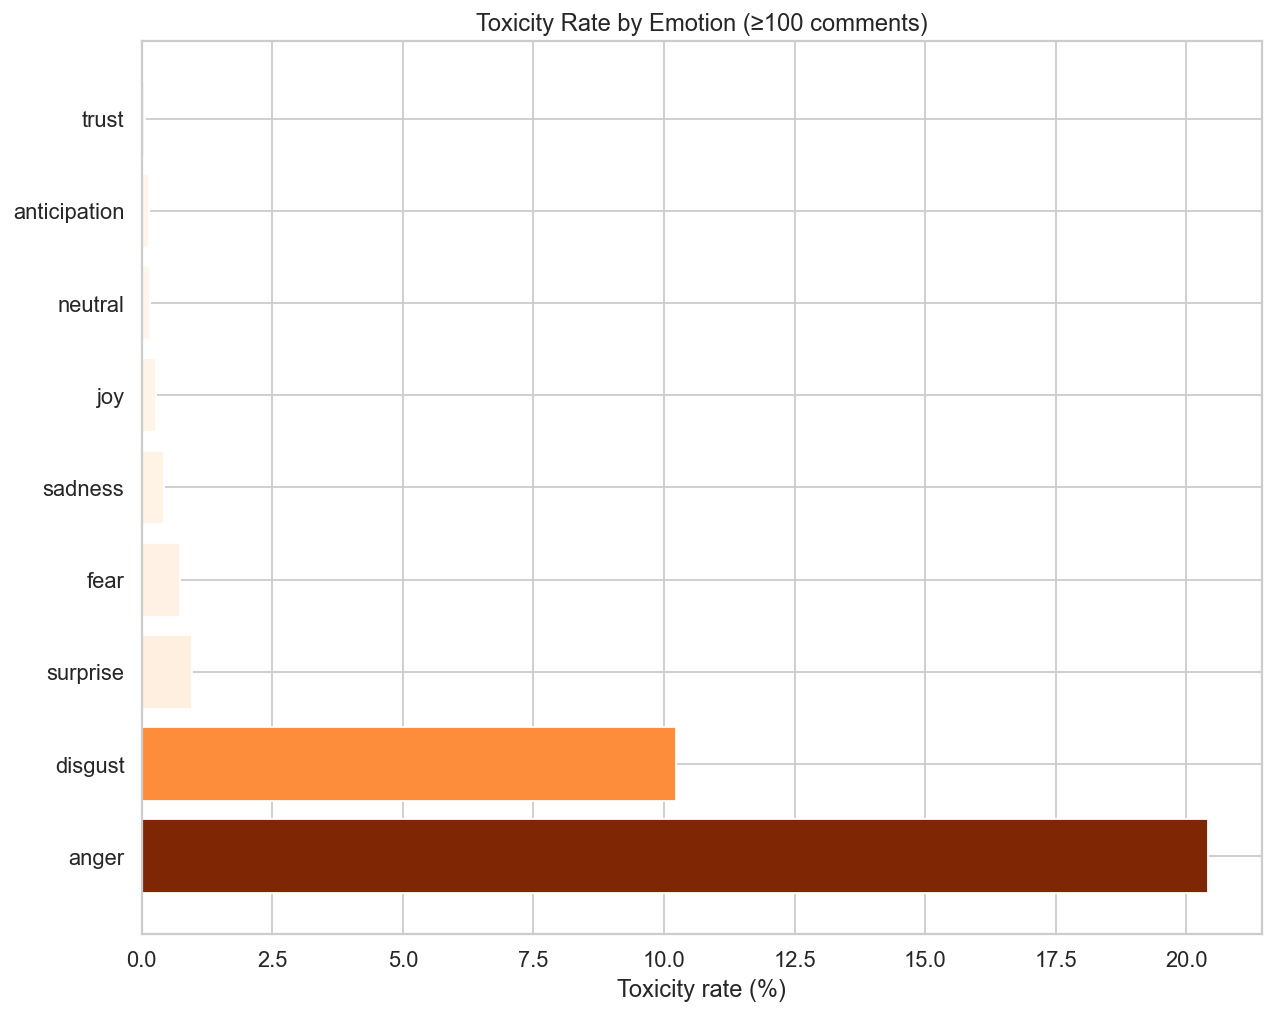

In [255]:
# Emotion toxicity rate — ranked
em_tox = (
    df.groupby('emotion')
      .agg(n=('comment_id','count'), tox_n=('is_toxic','sum'))
      .assign(tox_rate=lambda x: x['tox_n'] / x['n'] * 100)
      .query('n >= 100')
      .sort_values('tox_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(em_tox.index, em_tox['tox_rate'],
        color=plt.cm.Oranges(em_tox['tox_rate'] / em_tox['tox_rate'].max()))
ax.set_xlabel('Toxicity rate (%)')
ax.set_title('Toxicity Rate by Emotion (≥100 comments)')
plt.tight_layout()
plt.savefig(OUT / '11_toxicity_by_emotion.png', dpi=300)
plt.savefig(OUT / '11_toxicity_by_emotion.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

---
## 6. Topic → Sentiment / Emotion / Toxicity

We use post-level signals as proxy topics: `media_type`, `is_paid_partnership`, `n_hashtags` quartile, and the `llm_vibe` from room analysis.

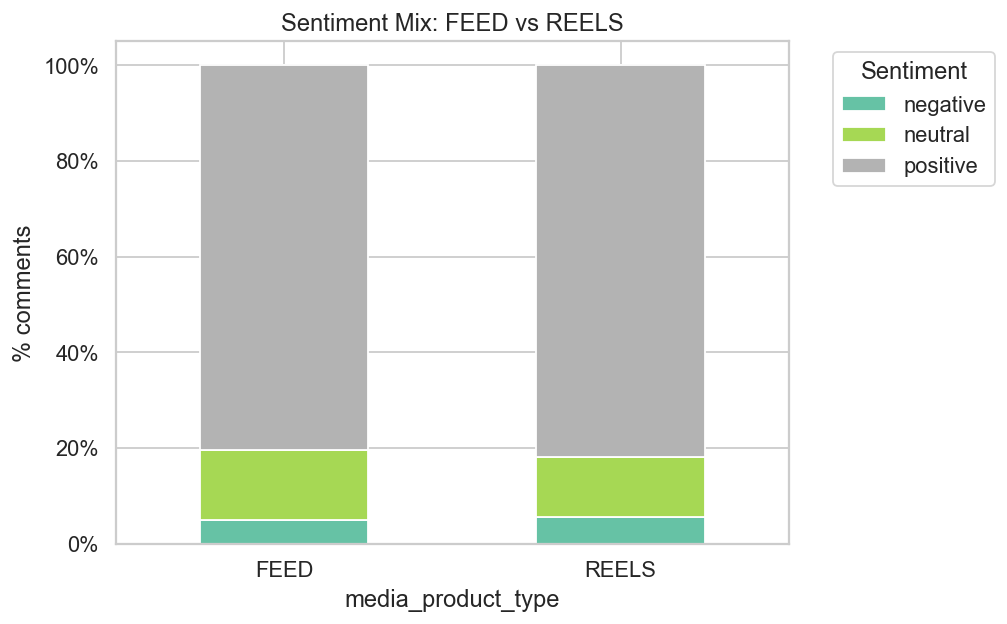

In [256]:
# 6.1 Sentiment x media_product_type (FEED / REELS) stacked bar
if 'media_product_type' in df.columns:
    mt_sent = (
        df.dropna(subset=['media_product_type'])
          .groupby(['media_product_type','sentiment']).size().reset_index(name='n')
    )
    mt_sent['pct'] = mt_sent.groupby('media_product_type')['n'].transform(lambda x: x / x.sum() * 100)
    mt_pivot = mt_sent.pivot(index='media_product_type', columns='sentiment', values='pct').fillna(0)

    ax = mt_pivot.plot.bar(stacked=True, figsize=(8, 5), colormap='Set2', rot=0)
    ax.set_title('Sentiment Mix: FEED vs REELS')
    ax.set_ylabel('% comments')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUT / '12_sentiment_by_mediatype.png', dpi=300)
    plt.savefig(OUT / '12_sentiment_by_mediatype.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


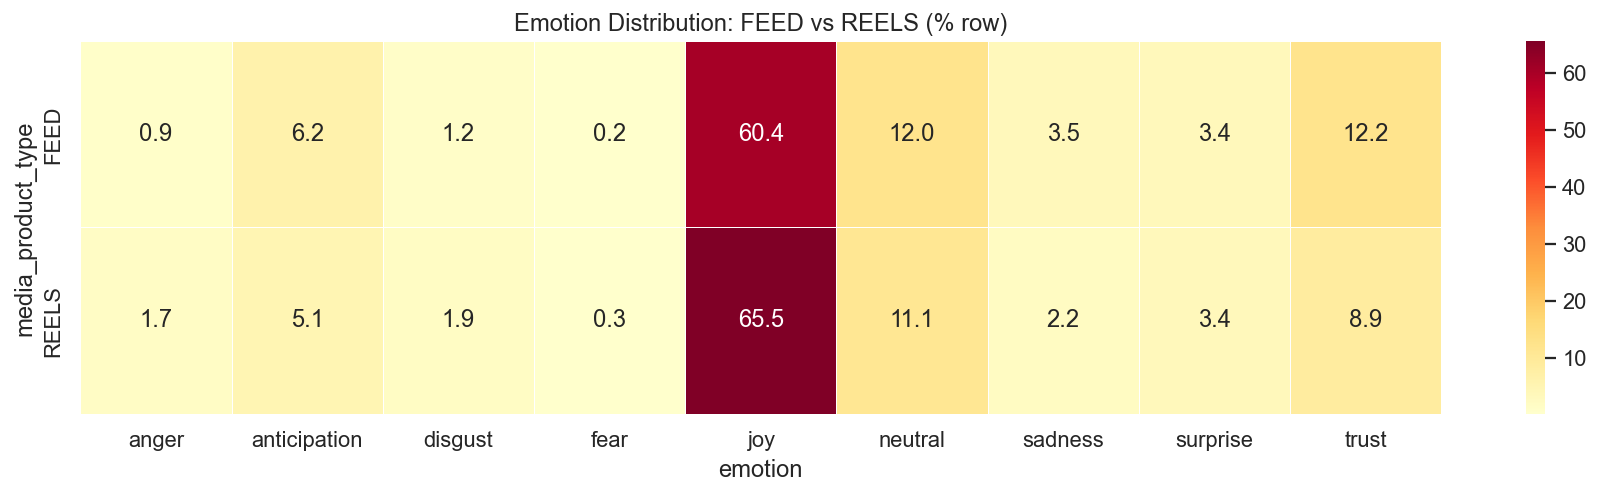

In [257]:
# 6.2 Emotion breakdown by media_product_type (FEED / REELS)
if 'media_product_type' in df.columns:
    top_em12 = df['emotion'].value_counts().head(12).index
    _mask_mt = df['emotion'].isin(top_em12) & df['media_product_type'].notna()
    ct_mt = pd.crosstab(
        df.loc[_mask_mt, 'media_product_type'],
        df.loc[_mask_mt, 'emotion'],
        normalize='index'
    ) * 100

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(ct_mt, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=.3)
    ax.set_title('Emotion Distribution: FEED vs REELS (% row)')
    plt.tight_layout()
    plt.savefig(OUT / '13_emotion_by_mediatype.png', dpi=300)
    plt.savefig(OUT / '13_emotion_by_mediatype.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


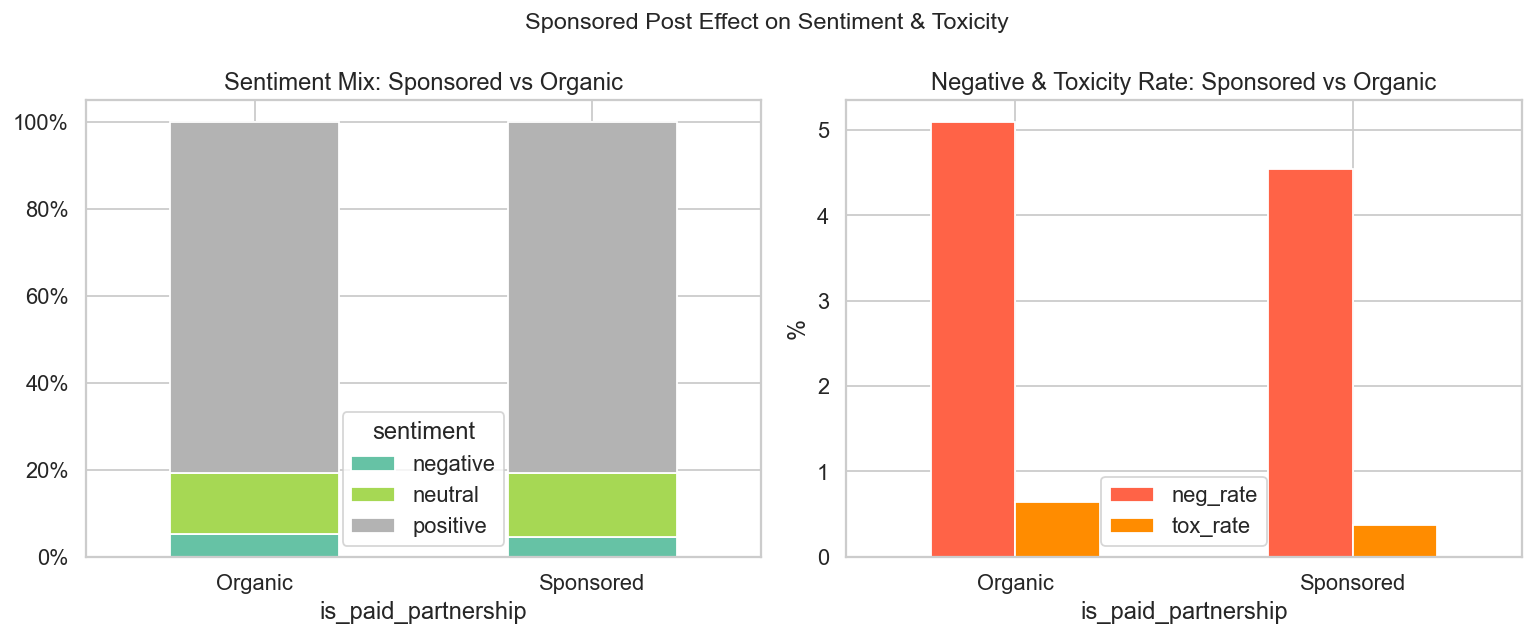

In [258]:
# 6.3 Sponsored vs organic: sentiment + toxicity
if 'is_paid_partnership' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    paid_sent = (
        df.groupby(['is_paid_partnership','sentiment']).size().reset_index(name='n')
    )
    paid_sent['pct'] = paid_sent.groupby('is_paid_partnership')['n'].transform(lambda x: x/x.sum()*100)
    paid_pivot = paid_sent.pivot(index='is_paid_partnership', columns='sentiment', values='pct').fillna(0)
    paid_pivot.index = paid_pivot.index.map({True:'Sponsored', False:'Organic', 1:'Sponsored', 0:'Organic'})
    paid_pivot.plot.bar(stacked=True, ax=axes[0], colormap='Set2', rot=0)
    axes[0].set_title('Sentiment Mix: Sponsored vs Organic')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

    paid_agg = (
        df.groupby('is_paid_partnership')
          .agg(neg_rate=('is_negative','mean'), tox_rate=('is_toxic','mean'))
          .mul(100)
    )
    paid_agg.index = paid_agg.index.map({True:'Sponsored', False:'Organic', 1:'Sponsored', 0:'Organic'})
    paid_agg.plot.bar(ax=axes[1], color=['tomato','darkorange'], rot=0)
    axes[1].set_title('Negative & Toxicity Rate: Sponsored vs Organic')
    axes[1].set_ylabel('%')

    plt.suptitle('Sponsored Post Effect on Sentiment & Toxicity', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / '14_sponsored_sentiment.png', dpi=300)
    plt.savefig(OUT / '14_sponsored_sentiment.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


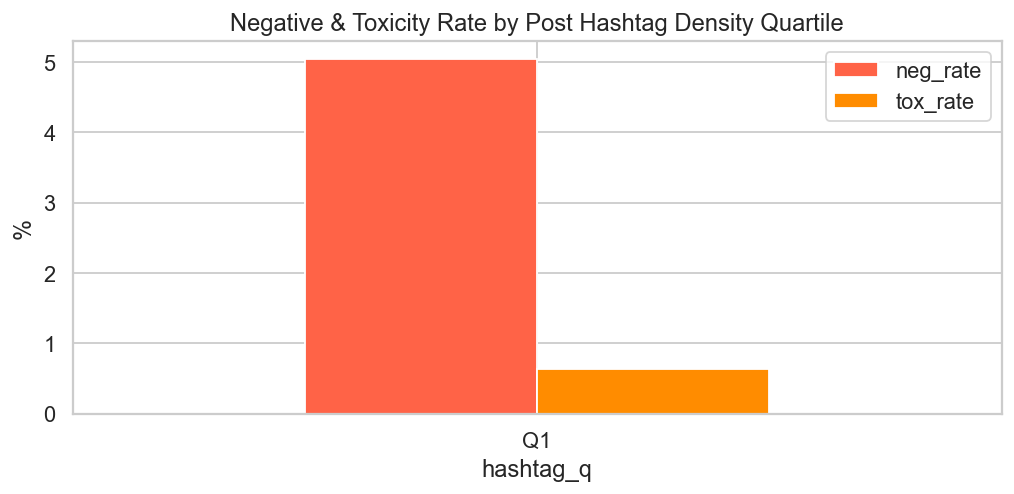

In [259]:
# 6.4 Hashtag density quartile vs sentiment & toxicity
if 'n_hashtags' in df.columns:
    # qcut with duplicates='drop' may yield <4 bins; let pandas label, then rename
    hq = pd.qcut(df['n_hashtags'].fillna(0), q=4, duplicates='drop')
    df['hashtag_q'] = hq.cat.rename_categories(
        [f'Q{i+1}' for i in range(len(hq.cat.categories))]
    )
    hash_agg = (
        df.groupby('hashtag_q', observed=True)
          .agg(neg_rate=('is_negative','mean'), tox_rate=('is_toxic','mean'), n=('comment_id','count'))
          .mul({'neg_rate':100,'tox_rate':100,'n':1})
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    hash_agg[['neg_rate','tox_rate']].plot.bar(ax=ax, rot=0, color=['tomato','darkorange'])
    ax.set_title('Negative & Toxicity Rate by Post Hashtag Density Quartile')
    ax.set_ylabel('%')
    plt.tight_layout()
    plt.savefig(OUT / '15_hashtag_q_sentiment.png', dpi=300)
    plt.savefig(OUT / '15_hashtag_q_sentiment.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


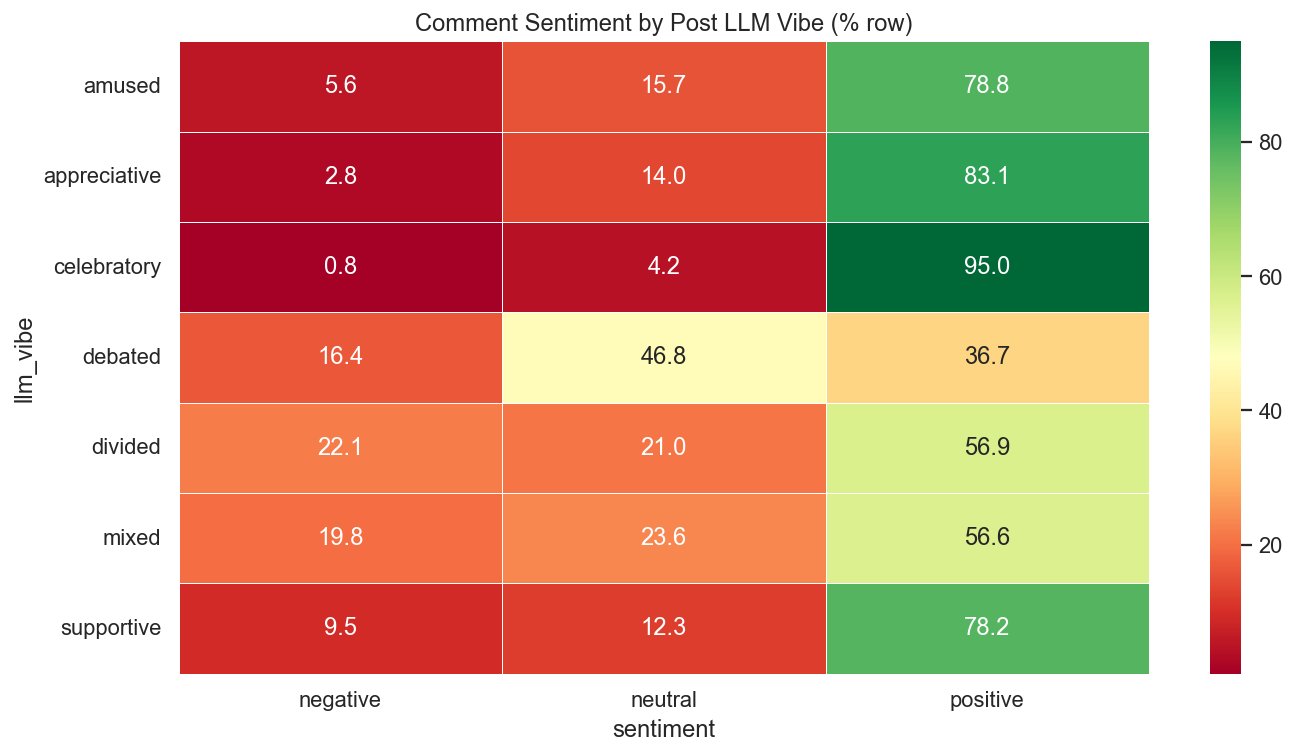

In [260]:
# 6.5 Room LLM vibe vs comment-level sentiment
if 'llm_vibe' in df.columns:
    top_vibes = df['llm_vibe'].value_counts().head(10).index
    mask_v = df['llm_vibe'].isin(top_vibes)
    ct_vibe = pd.crosstab(df.loc[mask_v, 'llm_vibe'], df.loc[mask_v, 'sentiment'],
                          normalize='index') * 100

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(ct_vibe, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, linewidths=.4)
    ax.set_title('Comment Sentiment by Post LLM Vibe (% row)')
    plt.tight_layout()
    plt.savefig(OUT / '16_vibe_sentiment.png', dpi=300)
    plt.savefig(OUT / '16_vibe_sentiment.svg', dpi=300, transparent=True)
    plt.show()

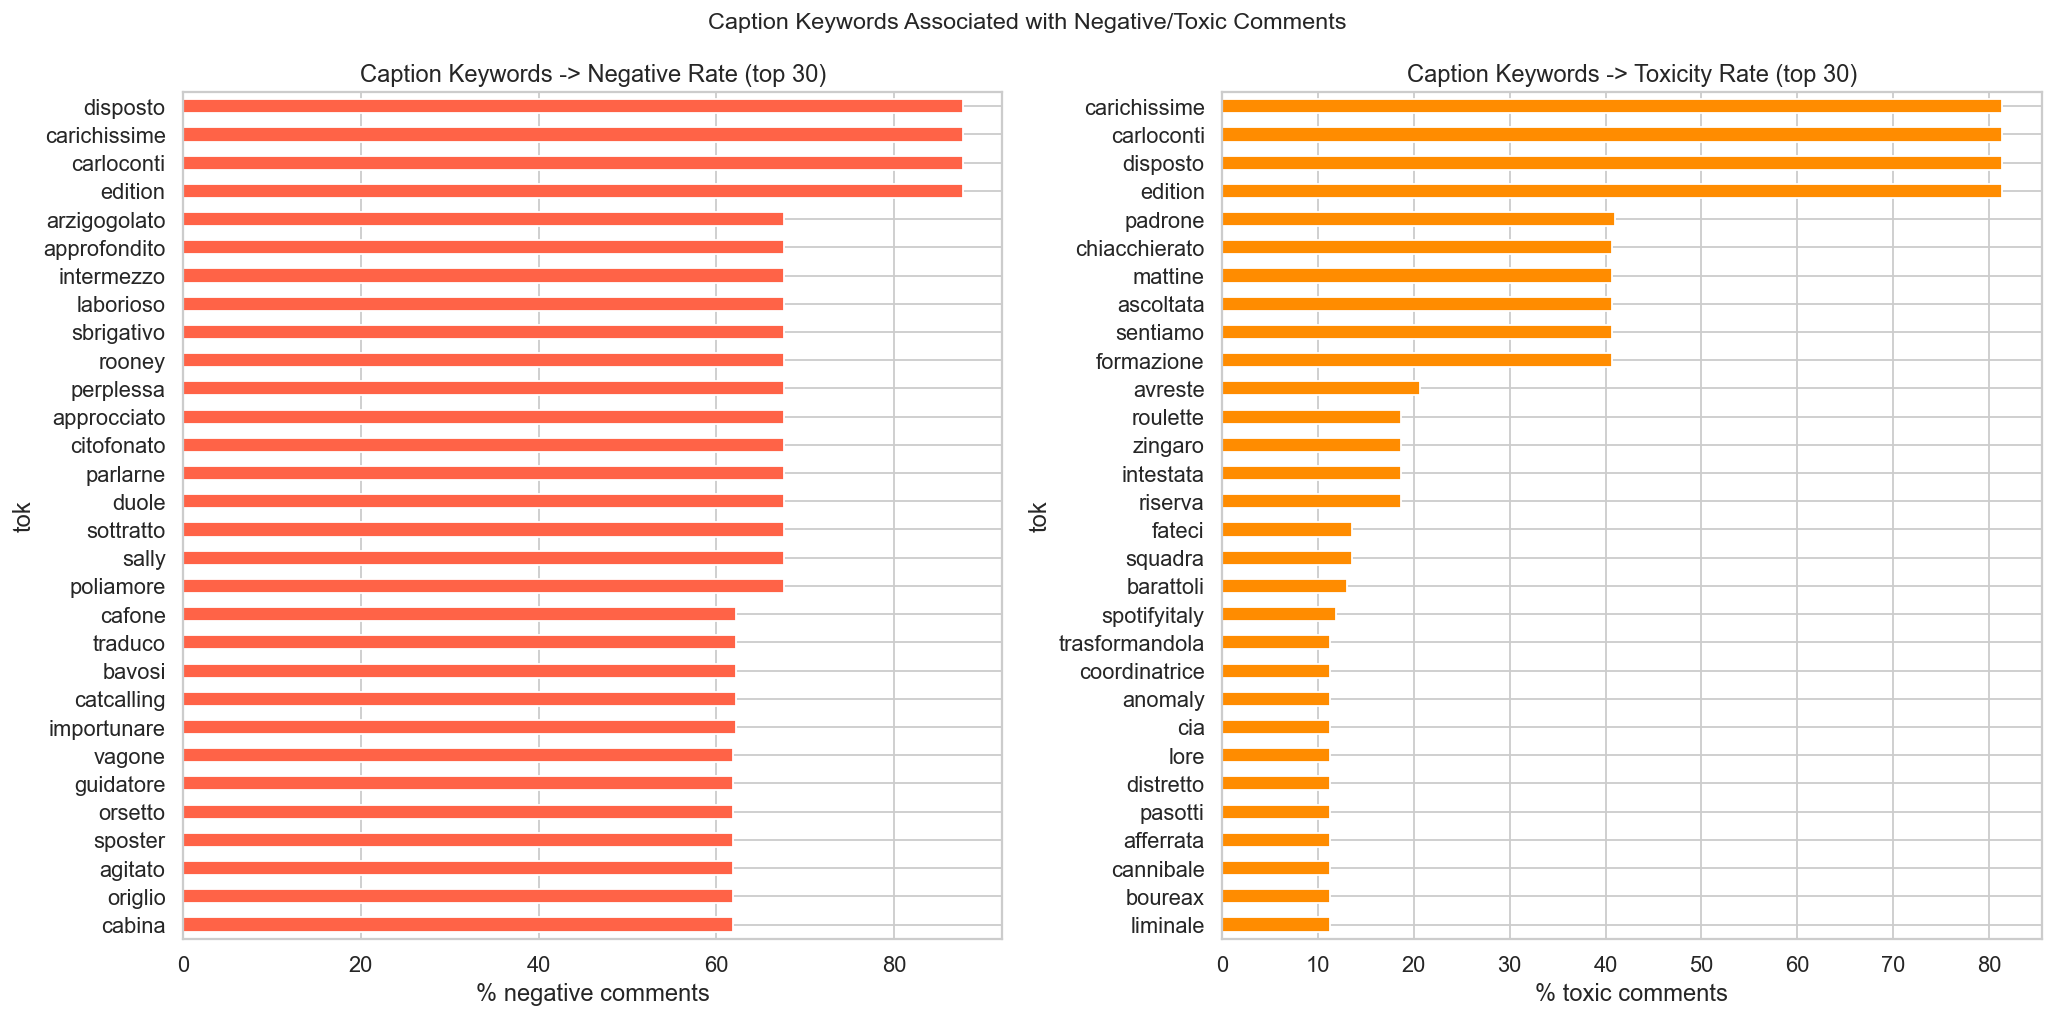

In [261]:
# 6.6 Caption keyword -> negative / toxic rate  (post-level aggregation, memory-safe)
if 'caption' in df.columns:
    import re

    stop = {'the','a','an','and','or','but','in','on','at','to','for','of','with',
            'is','it','this','that','i','my','your','we','our','are','be','was',
            'have','has','not','so','as','do','if','by','from','he','she','they',
            'all','can','will','just','no','more','than','its','also','up','out',
            'one','s','t','m','re','ve','ll','d','about','when','what','how'}

    # 1) post-level stats (tiny: ~1.5k rows)
    post_agg = (
        df.groupby('media_id')
          .agg(n=('comment_id','count'),
               neg_n=('is_negative','sum'),
               tox_n=('is_toxic','sum'))
          .assign(neg_rate=lambda x: x['neg_n'] / x['n'],
                  tox_rate=lambda x: x['tox_n'] / x['n'])
          .reset_index()
    )

    # 2) tokenise captions at post level (still ~1.5k rows)
    cap = df[['media_id','caption']].drop_duplicates('media_id').copy()
    def toks(c):
        if not c or not isinstance(c, str): return []
        return list({t for t in re.findall(r'[a-z]+', c.lower())
                     if t not in stop and len(t) > 2})
    cap['tok'] = cap['caption'].map(toks)
    cap_exp = cap[['media_id','tok']].explode('tok').dropna(subset=['tok'])

    # 3) join word membership onto post stats (not onto comments)
    kw_post = cap_exp.merge(post_agg, on='media_id', how='inner')

    # 4) aggregate across posts that share the same word
    kw_stats = (
        kw_post.groupby('tok')
               .agg(n_posts=('media_id','count'),
                    n_comments=('n','sum'),
                    neg_rate=('neg_rate','mean'),
                    tox_rate=('tox_rate','mean'))
    )
    kw_stats = kw_stats[kw_stats['n_comments'] >= 50]

    top_neg = kw_stats.sort_values('neg_rate', ascending=False).head(30)
    top_tox = kw_stats.sort_values('tox_rate', ascending=False).head(30)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    (top_neg['neg_rate'] * 100).iloc[::-1].plot.barh(ax=axes[0], color='tomato')
    axes[0].set_title('Caption Keywords -> Negative Rate (top 30)')
    axes[0].set_xlabel('% negative comments')

    (top_tox['tox_rate'] * 100).iloc[::-1].plot.barh(ax=axes[1], color='darkorange')
    axes[1].set_title('Caption Keywords -> Toxicity Rate (top 30)')
    axes[1].set_xlabel('% toxic comments')

    plt.suptitle('Caption Keywords Associated with Negative/Toxic Comments', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / '17_caption_keywords.png', dpi=300)
    plt.savefig(OUT / '17_caption_keywords.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


---
## 7. Persona & RFM Lens

Two user-level segmentations, both joined on `author_id`:
- `persona_codename` -- LLM personas from `user_personas_combined.parquet` (THE_CRITIC, THE_HATER, THE_SUPERFAN, ...) -- coverage ~21%
- `rfm_cluster_name` -- Mickey's named KMeans k=4 clusters on RCEDTG features (Passive regulars, Occasional Visitors, Established regulars, Brand advocates) -- coverage ~10%


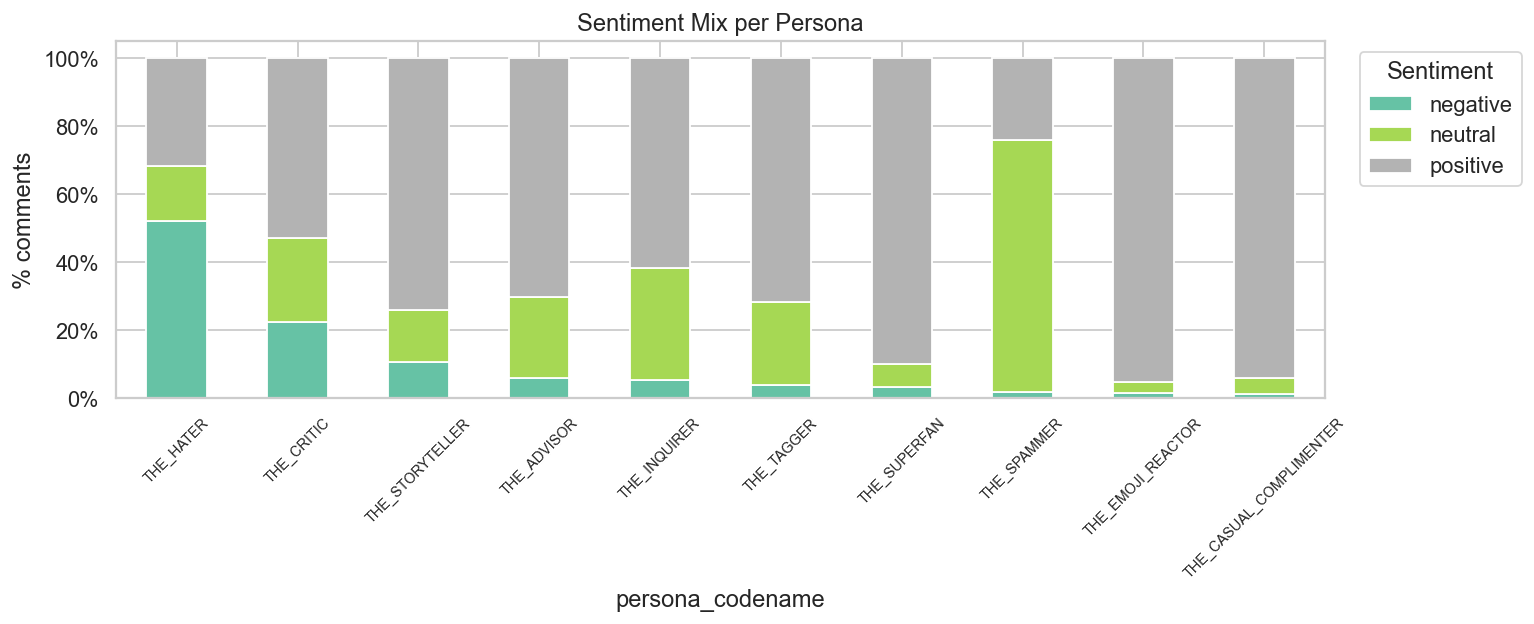

In [262]:
# 7.1 Sentiment mix per persona
if df['persona_codename'].notna().any():
    pc_sent = (
        df.dropna(subset=['persona_codename'])
          .groupby(['persona_codename','sentiment']).size().reset_index(name='n')
    )
    pc_sent['pct'] = pc_sent.groupby('persona_codename')['n'].transform(lambda x: x/x.sum()*100)
    pc_pivot = pc_sent.pivot(index='persona_codename', columns='sentiment', values='pct').fillna(0)
    sort_col = next((c for c in pc_pivot.columns if 'neg' in c.lower()), pc_pivot.columns[0])
    pc_pivot = pc_pivot.sort_values(sort_col, ascending=False)

    ax = pc_pivot.plot.bar(stacked=True, figsize=(12, 5), colormap='Set2', rot=45)
    ax.set_title('Sentiment Mix per Persona')
    ax.set_ylabel('% comments')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    plt.savefig(OUT / '18_persona_sentiment.png', dpi=300)
    plt.savefig(OUT / '18_persona_sentiment.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


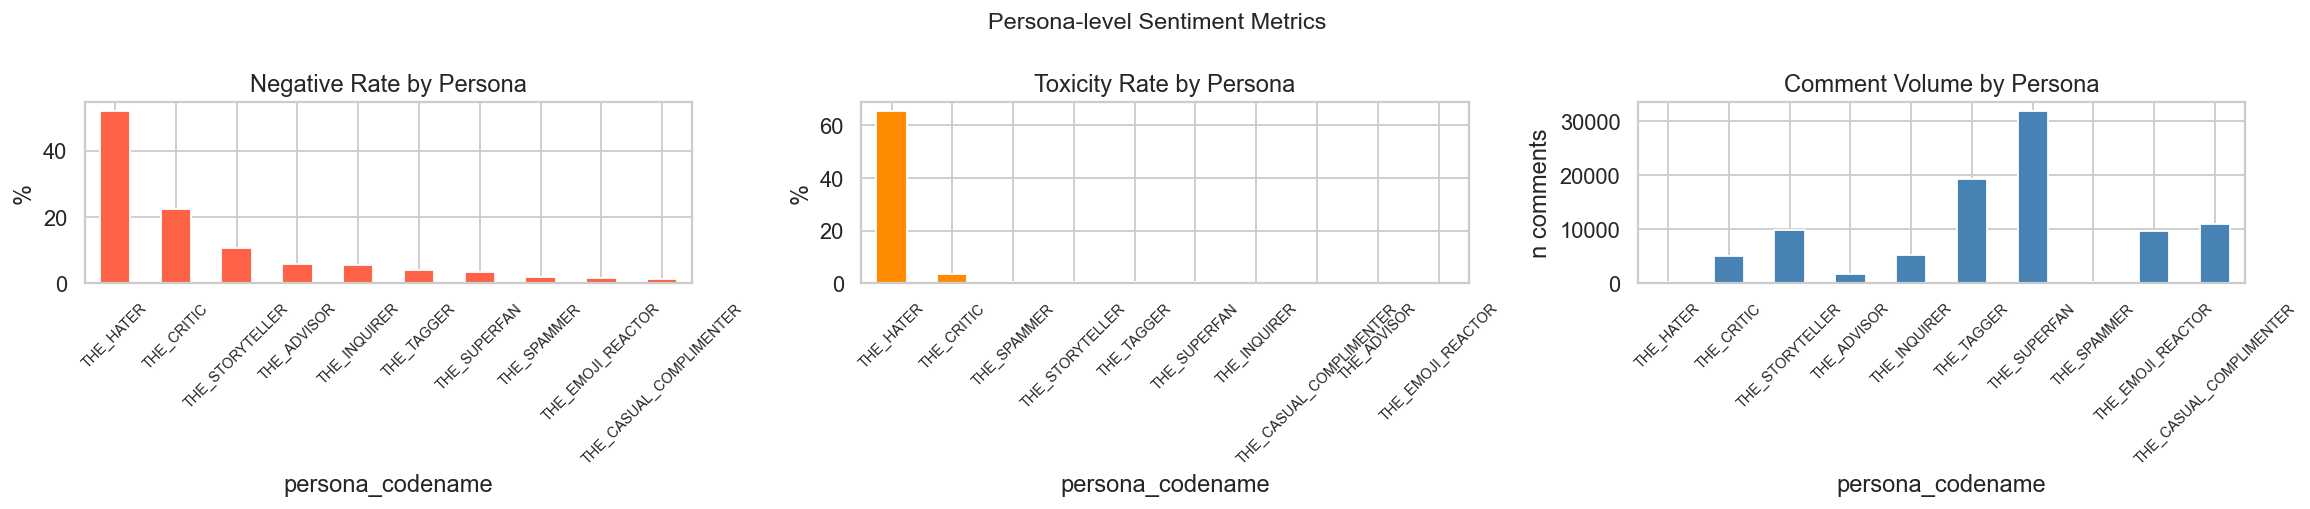

                          neg_rate   tox_rate  n_comments
persona_codename                                         
THE_HATER                52.023121  65.317919         173
THE_CRITIC               22.373697   3.448276        4988
THE_STORYTELLER          10.754659   0.600876        9819
THE_ADVISOR               5.919540   0.172414        1740
THE_INQUIRER              5.547170   0.283019        5300
THE_TAGGER                3.977889   0.459782       19357
THE_SUPERFAN              3.383459   0.375940       31920
THE_SPAMMER               1.851852   0.617284         324
THE_EMOJI_REACTOR         1.553277   0.165683        9657
THE_CASUAL_COMPLIMENTER   1.385957   0.220285       10895


In [263]:
# 7.2 Negative & toxicity rate per persona
if df['persona_codename'].notna().any():
    persona_agg = (
        df.dropna(subset=['persona_codename'])
          .groupby('persona_codename')
          .agg(neg_rate=('is_negative','mean'),
               tox_rate=('is_toxic','mean'),
               n_comments=('comment_id','count'))
          .assign(neg_rate=lambda x: x['neg_rate']*100, tox_rate=lambda x: x['tox_rate']*100)
          .sort_values('neg_rate', ascending=False)
    )
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    persona_agg['neg_rate'].plot.bar(ax=axes[0], color='tomato', rot=45)
    axes[0].set_title('Negative Rate by Persona'); axes[0].set_ylabel('%')
    persona_agg['tox_rate'].sort_values(ascending=False).plot.bar(ax=axes[1], color='darkorange', rot=45)
    axes[1].set_title('Toxicity Rate by Persona'); axes[1].set_ylabel('%')
    persona_agg['n_comments'].plot.bar(ax=axes[2], color='steelblue', rot=45)
    axes[2].set_title('Comment Volume by Persona'); axes[2].set_ylabel('n comments')
    for a in axes: a.tick_params(axis='x', labelsize=8)
    plt.suptitle('Persona-level Sentiment Metrics', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / '19_persona_metrics.png', dpi=300)
    plt.savefig(OUT / '19_persona_metrics.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()
    print(persona_agg.to_string())


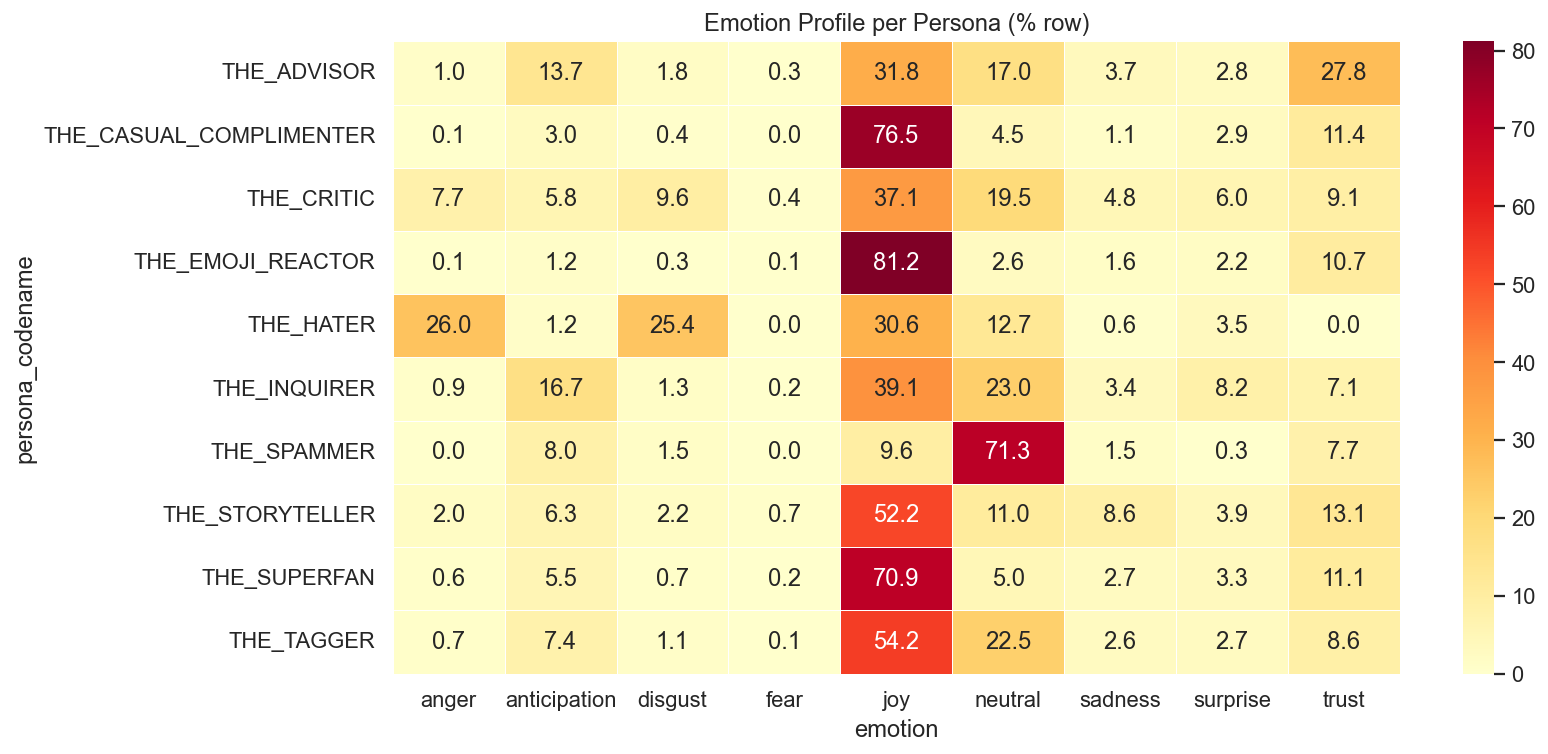

In [264]:
# 7.3 Emotion heatmap per persona
if df['persona_codename'].notna().any():
    top_em10 = df['emotion'].value_counts().head(10).index
    _mask_pc = df['emotion'].isin(top_em10) & df['persona_codename'].notna()
    ct_pc = pd.crosstab(
        df.loc[_mask_pc, 'persona_codename'],
        df.loc[_mask_pc, 'emotion'],
        normalize='index'
    ) * 100

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(ct_pc, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=.3)
    ax.set_title('Emotion Profile per Persona (% row)')
    plt.tight_layout()
    plt.savefig(OUT / '20_persona_emotion_heatmap.png', dpi=300)
    plt.savefig(OUT / '20_persona_emotion_heatmap.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()


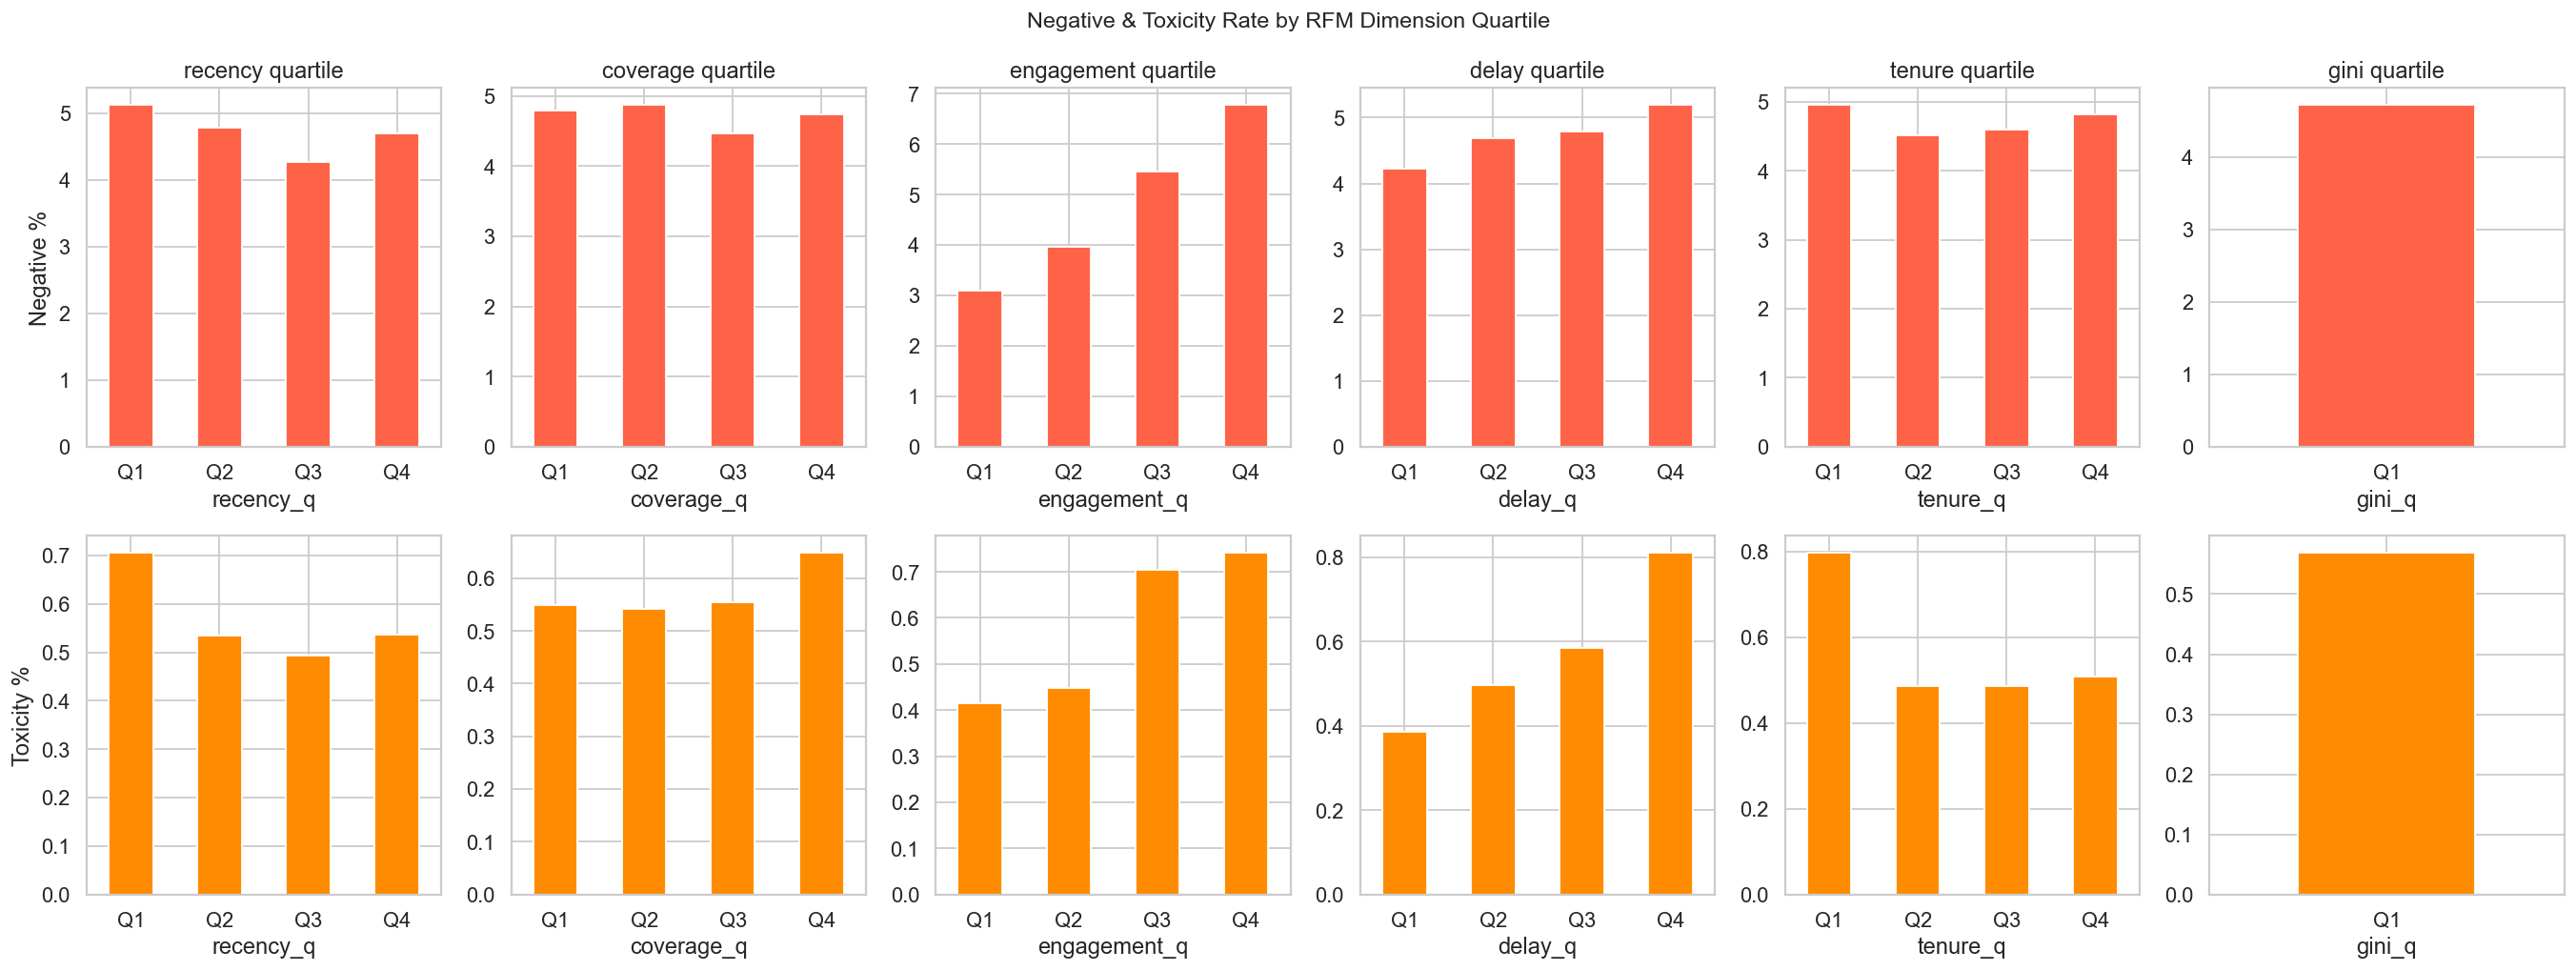

In [265]:
# 7.4 RFM dimension vs negativity / toxicity
rfm_dims = ['recency','coverage','engagement','delay','tenure','gini']
rfm_dims = [c for c in rfm_dims if c in df.columns and df[c].notna().any()]

if rfm_dims:
    n_dims = len(rfm_dims)
    fig, axes = plt.subplots(2, n_dims, figsize=(n_dims * 3.5, 8))
    if n_dims == 1:
        axes = axes.reshape(2, 1)

    for i, dim in enumerate(rfm_dims):
        # robust quartile binning: drop dup edges, label by actual bin count
        binned = pd.qcut(df[dim], q=4, duplicates='drop')
        df[f'{dim}_q'] = binned.cat.rename_categories(
            [f'Q{k+1}' for k in range(len(binned.cat.categories))]
        )
        agg_q = (
            df.groupby(f'{dim}_q', observed=True)
              .agg(neg=('is_negative','mean'), tox=('is_toxic','mean'))
              .mul(100)
        )
        agg_q['neg'].plot.bar(ax=axes[0, i], color='tomato', rot=0)
        axes[0, i].set_title(f'{dim} quartile')
        agg_q['tox'].plot.bar(ax=axes[1, i], color='darkorange', rot=0)

    axes[0, 0].set_ylabel('Negative %')
    axes[1, 0].set_ylabel('Toxicity %')
    fig.suptitle('Negative & Toxicity Rate by RFM Dimension Quartile', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / '21_rfm_sentiment.png', dpi=300)
    plt.savefig(OUT / '21_rfm_sentiment.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()
else:
    print('No RFM dimensions available (check join coverage).')


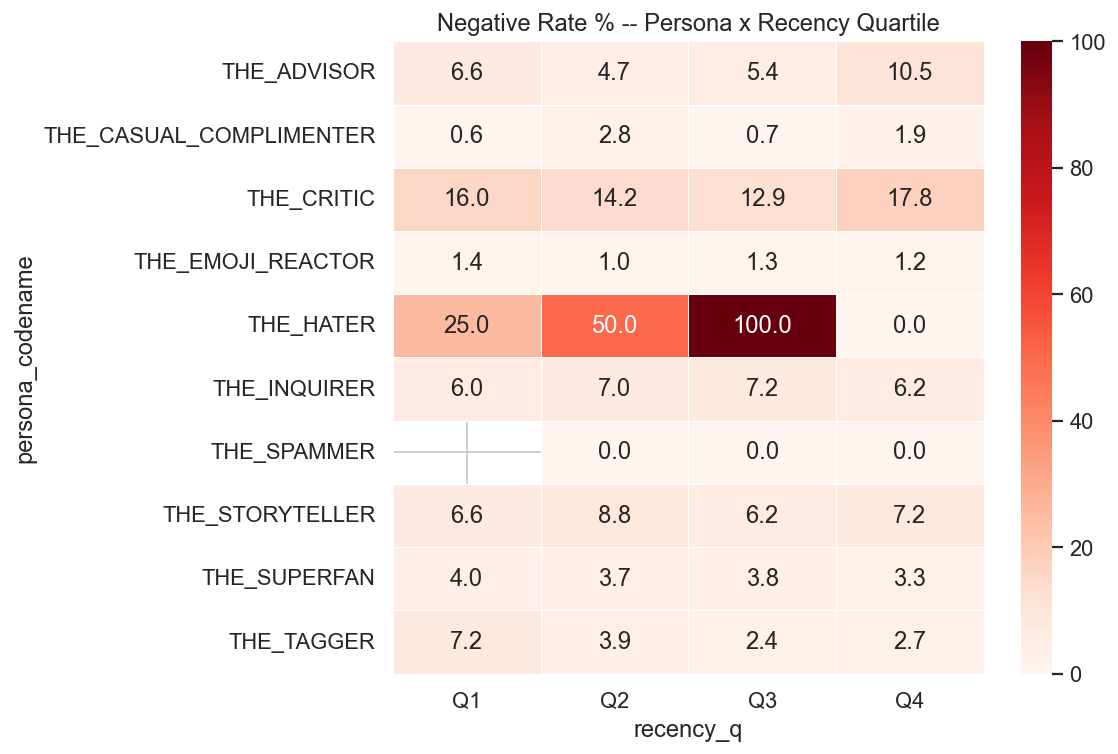

In [266]:
# 7.5 Persona x RFM recency: bivariate negative rate
if 'recency' in df.columns and df['persona_codename'].notna().any() and df['recency'].notna().any():
    rq = pd.qcut(df['recency'], q=4, duplicates='drop')
    df['recency_q'] = rq.cat.rename_categories([f'Q{i+1}' for i in range(len(rq.cat.categories))])
    pivot_cr = (
        df.dropna(subset=['persona_codename','recency_q'])
          .groupby(['persona_codename','recency_q'], observed=True)['is_negative']
          .mean().mul(100).unstack('recency_q')
    )
    if pivot_cr.size:
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.heatmap(pivot_cr, annot=True, fmt='.1f', cmap='Reds', ax=ax, linewidths=.4)
        ax.set_title('Negative Rate % -- Persona x Recency Quartile')
        plt.tight_layout()
        plt.savefig(OUT / '22_persona_rfm_negative.png', dpi=300)
        plt.savefig(OUT / '22_persona_rfm_negative.svg', dpi=300, transparent=True)  # --- IGNORE ---
        plt.show()


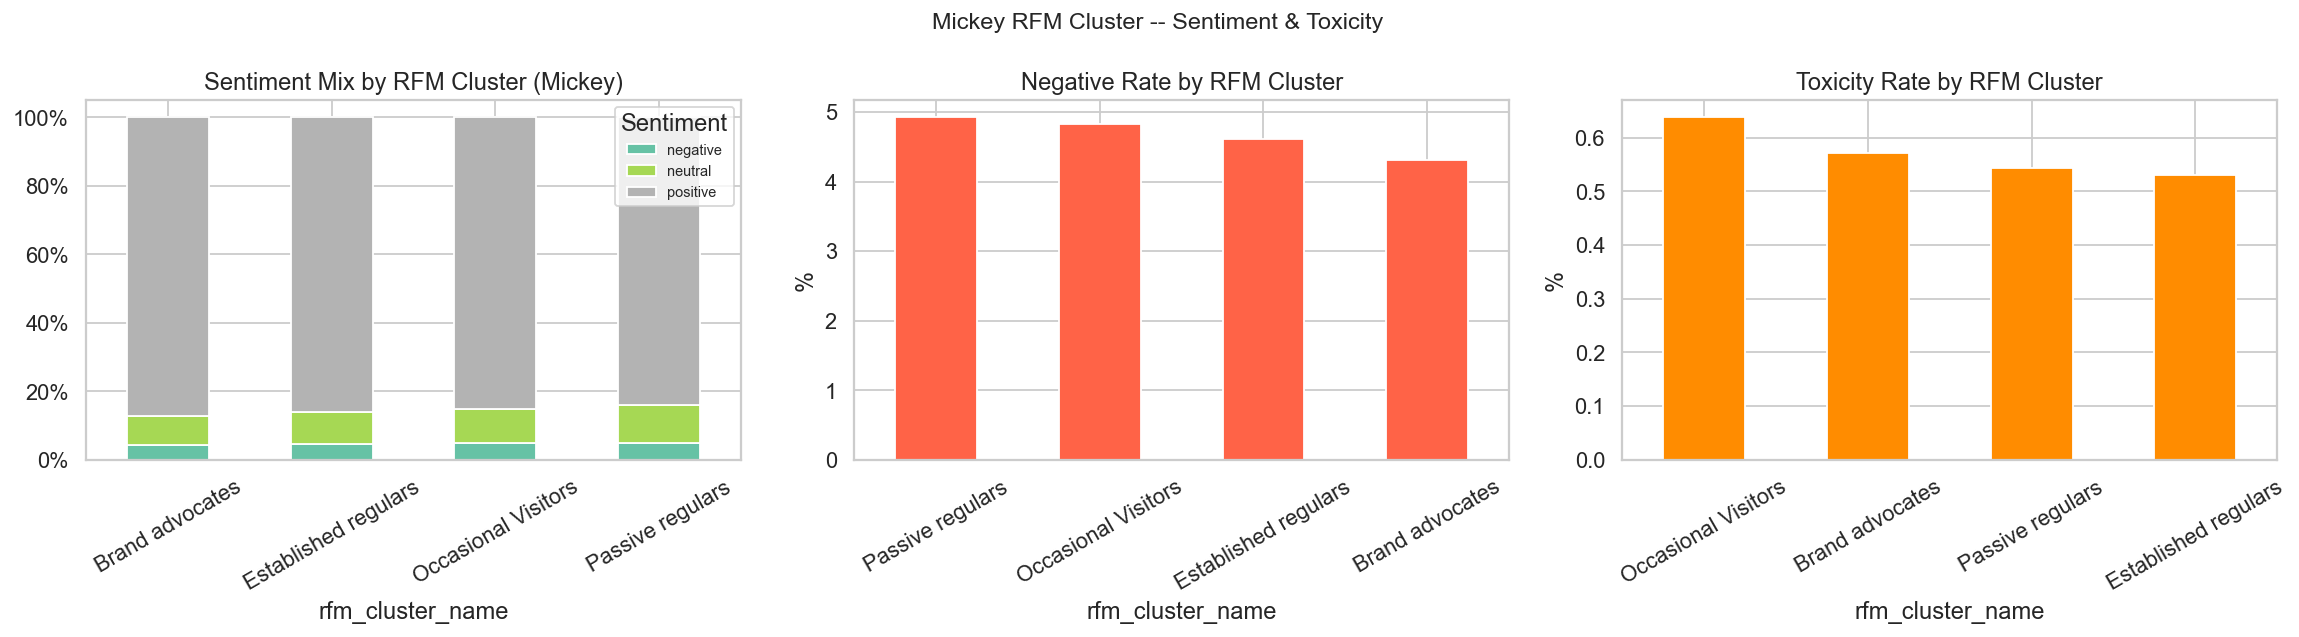

                      neg_rate  tox_rate      n
rfm_cluster_name                               
Passive regulars      4.924707  0.543457  50602
Occasional Visitors   4.824792  0.637803  39981
Established regulars  4.614758  0.529798  41714
Brand advocates       4.312680  0.571356  23628


In [267]:
# 7.6 Mickey named RFM clusters: sentiment mix + negative/toxic rates
if df['rfm_cluster_name'].notna().any():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    rfm_sent = (
        df.dropna(subset=['rfm_cluster_name'])
          .groupby(['rfm_cluster_name','sentiment']).size().reset_index(name='n')
    )
    rfm_sent['pct'] = rfm_sent.groupby('rfm_cluster_name')['n'].transform(lambda x: x/x.sum()*100)
    rfm_pivot = rfm_sent.pivot(index='rfm_cluster_name', columns='sentiment', values='pct').fillna(0)
    rfm_pivot.plot.bar(stacked=True, ax=axes[0], colormap='Set2', rot=30)
    axes[0].set_title('Sentiment Mix by RFM Cluster (Mickey)')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].legend(title='Sentiment', fontsize=8)

    rfm_agg = (
        df.dropna(subset=['rfm_cluster_name'])
          .groupby('rfm_cluster_name')
          .agg(neg_rate=('is_negative','mean'), tox_rate=('is_toxic','mean'), n=('comment_id','count'))
          .assign(neg_rate=lambda x: x['neg_rate']*100, tox_rate=lambda x: x['tox_rate']*100)
          .sort_values('neg_rate', ascending=False)
    )
    rfm_agg['neg_rate'].plot.bar(ax=axes[1], color='tomato', rot=30)
    axes[1].set_title('Negative Rate by RFM Cluster'); axes[1].set_ylabel('%')
    rfm_agg['tox_rate'].sort_values(ascending=False).plot.bar(ax=axes[2], color='darkorange', rot=30)
    axes[2].set_title('Toxicity Rate by RFM Cluster'); axes[2].set_ylabel('%')

    plt.suptitle('Mickey RFM Cluster -- Sentiment & Toxicity', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / '22b_rfm_named_cluster_sentiment.png', dpi=300)
    plt.savefig(OUT / '22b_rfm_named_cluster_sentiment.svg', dpi=300, transparent=True)  # --- IGNORE ---
    plt.show()
    print(rfm_agg.to_string())


---
## 8. Linguistic Features (comments_ml) vs Negativity & Toxicity

In [268]:
# Define ML feature columns (from comments_ml)
ml_feature_cols = [
    'text_length','word_count','emoji_count','unique_emoji_count',
    'emoji_entropy','emoji_variety_ratio','emoji_per_word_ratio',
    'url_count','mention_count','hashtag_count',
    'exclamation_count','question_count','avg_word_length',
    'has_numbers','has_links'
]
ml_feature_cols = [c for c in ml_feature_cols if c in df.columns]
print(f'Available ML features: {ml_feature_cols}')

Available ML features: ['text_length', 'word_count', 'emoji_count', 'unique_emoji_count', 'emoji_entropy', 'emoji_variety_ratio', 'emoji_per_word_ratio', 'url_count', 'mention_count', 'hashtag_count', 'exclamation_count', 'question_count', 'avg_word_length', 'has_numbers', 'has_links']


In [269]:
# Point-biserial correlation of each linguistic feature with is_negative / is_toxic
from scipy import stats

corr_rows = {}
for col in ml_feature_cols:
    x = pd.to_numeric(df[col], errors='coerce')
    rec = {}
    for tgt, name in [('is_negative', 'r_negative'), ('is_toxic', 'r_toxic')]:
        y = df[tgt].astype(float)
        m = x.notna() & y.notna()
        if m.sum() > 2 and x[m].nunique() > 1 and y[m].nunique() > 1:
            r, _ = stats.pointbiserialr(y[m], x[m])
        else:
            r = float('nan')
        rec[name] = r
    corr_rows[col] = rec

corr_df = pd.DataFrame(corr_rows).T  # index = feature, cols = r_negative, r_toxic
corr_df = corr_df.dropna(how='all')
print(corr_df.sort_values('r_negative').to_string())


                      r_negative   r_toxic
unique_emoji_count     -0.078559 -0.040800
emoji_count            -0.067531 -0.025428
emoji_per_word_ratio   -0.064537 -0.023196
emoji_variety_ratio    -0.063367 -0.046238
emoji_entropy          -0.036484 -0.013992
avg_word_length        -0.026342 -0.002805
has_links               0.000127 -0.002253
exclamation_count       0.000413  0.005231
url_count               0.000591 -0.002191
mention_count           0.011486 -0.002508
hashtag_count           0.016358  0.028940
question_count          0.058807  0.021347
has_numbers             0.061876  0.010290
text_length             0.196715  0.038768
word_count              0.200077  0.040476


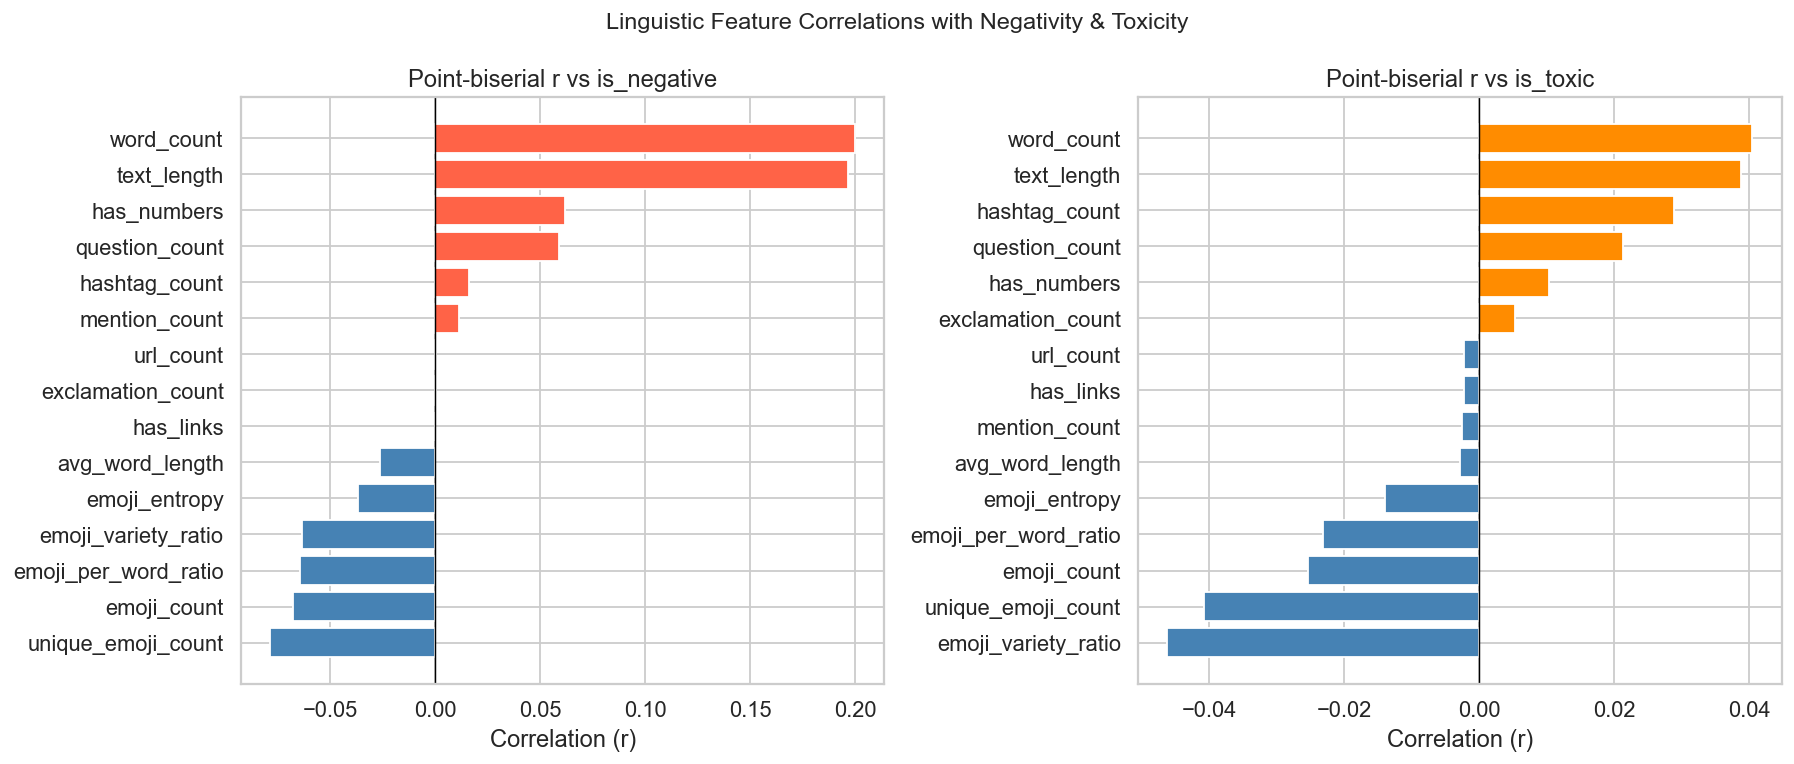

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

titles = {'r_negative': 'is_negative', 'r_toxic': 'is_toxic'}
colors = {'r_negative': 'tomato', 'r_toxic': 'darkorange'}

for ax, target in zip(axes, ['r_negative', 'r_toxic']):
    data = corr_df[target].sort_values()
    color = colors[target]
    ax.barh(data.index, data.values,
            color=[color if v > 0 else 'steelblue' for v in data.values])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Point-biserial r vs {titles[target]}')
    ax.set_xlabel('Correlation (r)')

plt.suptitle('Linguistic Feature Correlations with Negativity & Toxicity', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / '23_feature_correlations.png', dpi=300)
plt.savefig(OUT / '23_feature_correlations.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

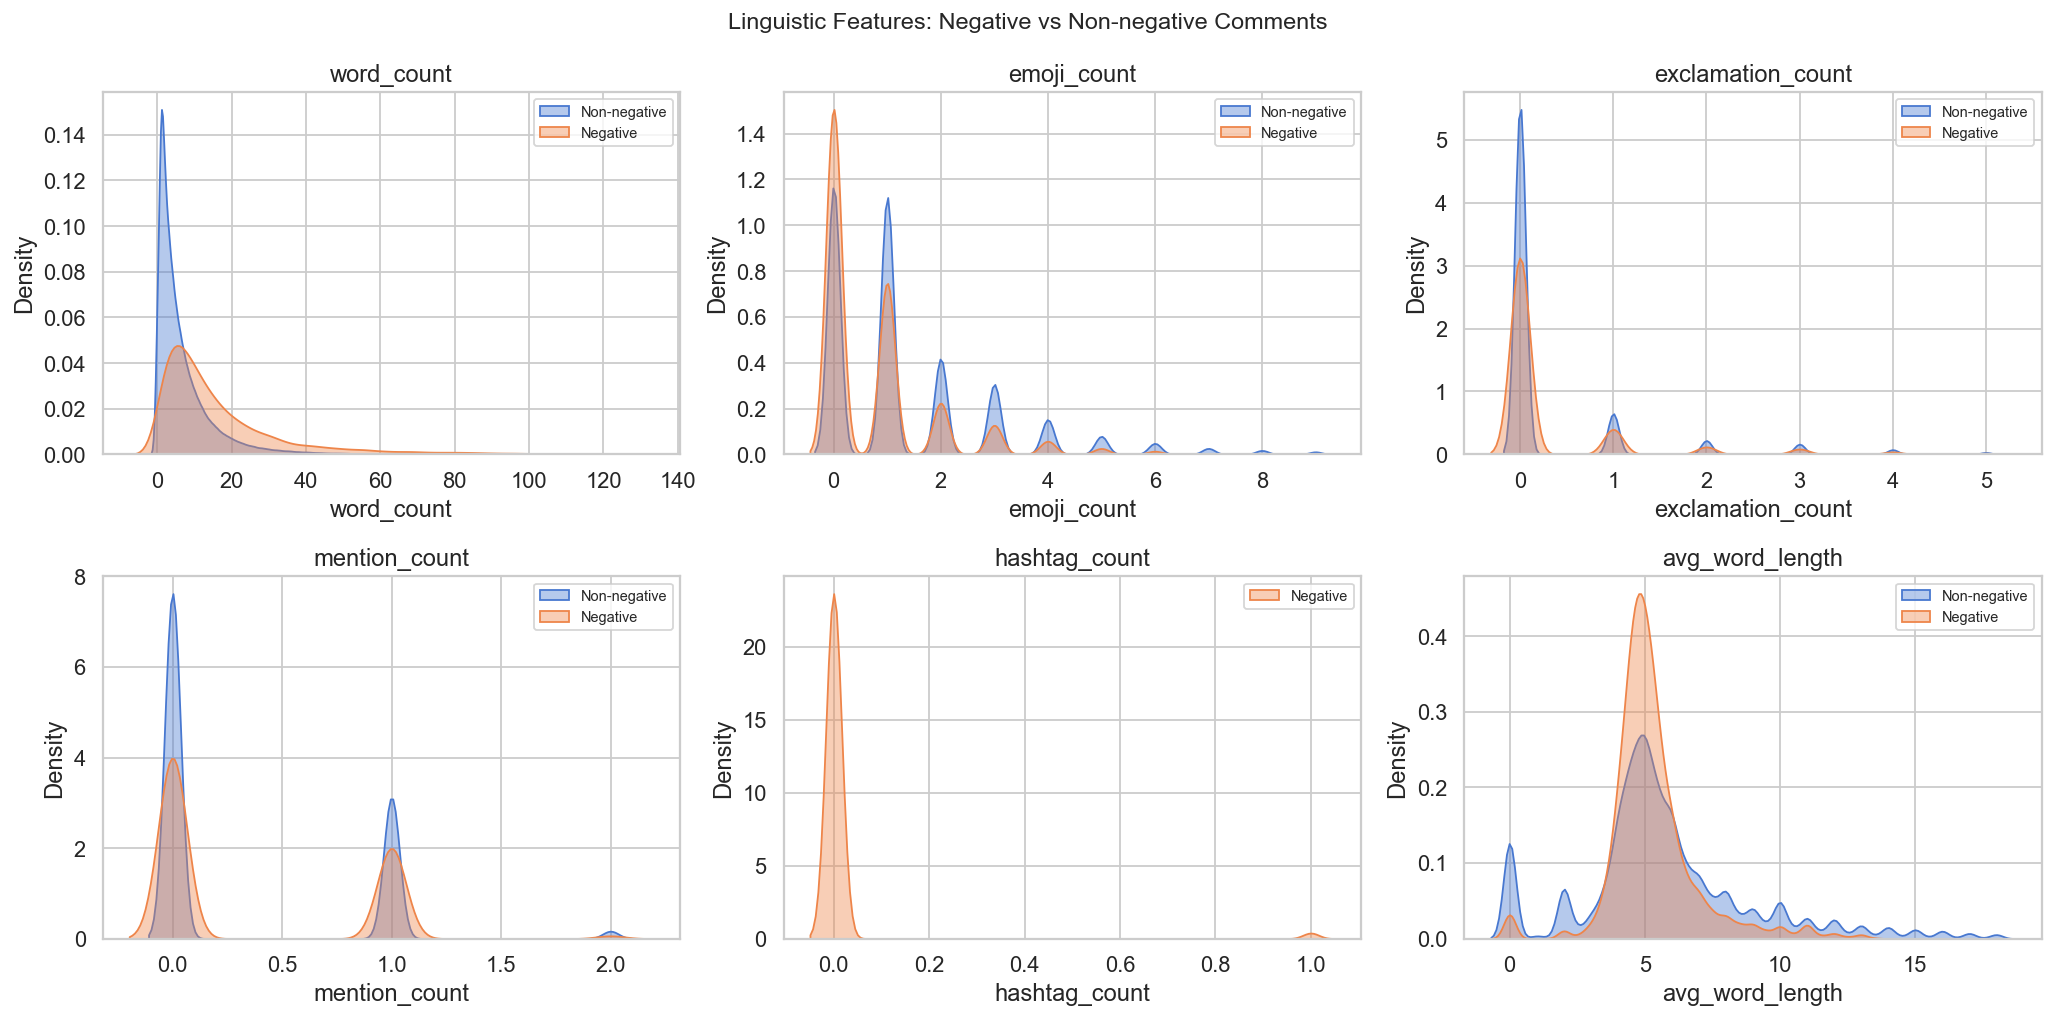

In [271]:
# Distribution of key linguistic features: negative vs non-negative
key_features = ['word_count','emoji_count','exclamation_count','mention_count',
                'hashtag_count','avg_word_length']
key_features = [c for c in key_features if c in df.columns]

n = len(key_features)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    for label, grp in df.groupby('is_negative'):
        vals = grp[col].dropna()
        vals = vals[vals <= vals.quantile(0.99)]  # clip outliers
        sns.kdeplot(vals, ax=ax, label='Negative' if label else 'Non-negative',
                    fill=True, alpha=0.4)
    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Linguistic Features: Negative vs Non-negative Comments', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / '24_feature_distributions.png', dpi=300)
plt.savefig(OUT / '24_feature_distributions.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

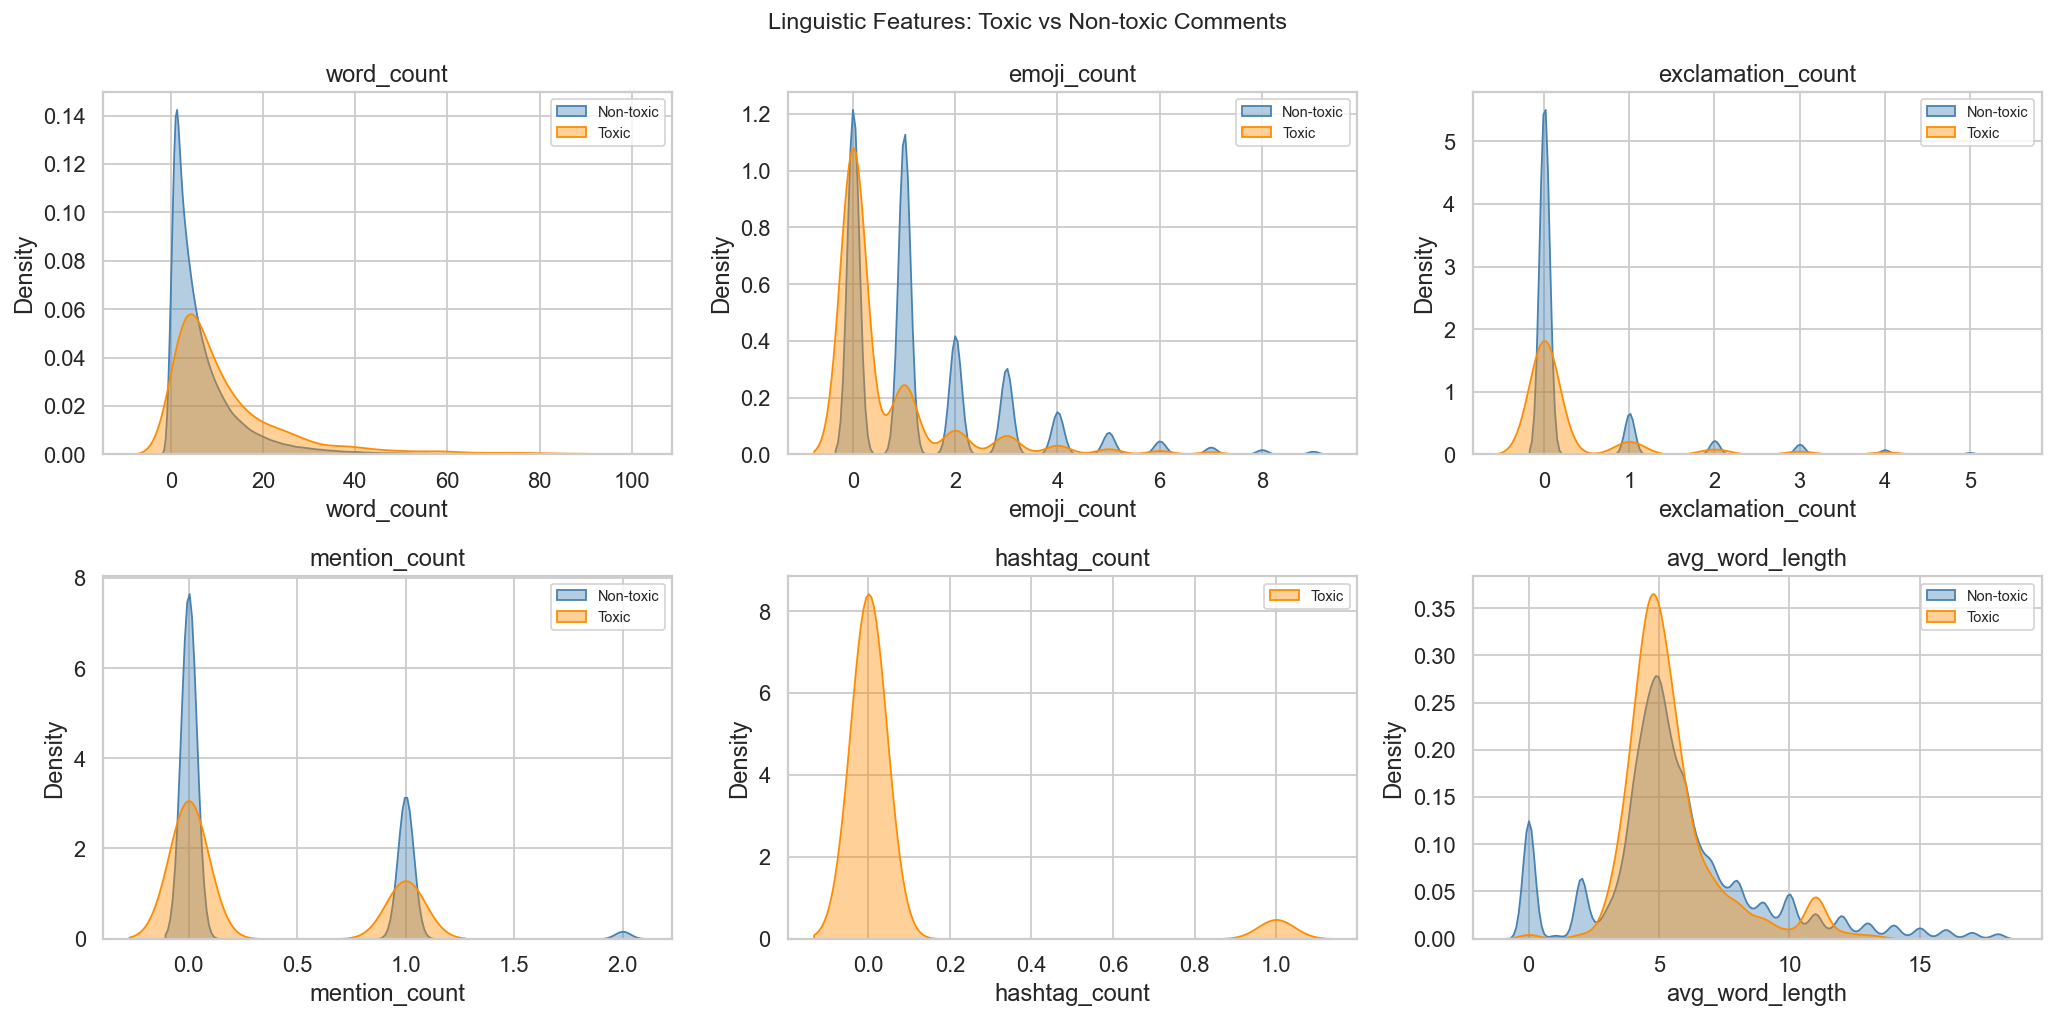

In [272]:
# Same but for toxic vs non-toxic
fig, axes = plt.subplots(2, (n+1)//2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    for label, grp in df.groupby('is_toxic'):
        vals = grp[col].dropna()
        vals = vals[vals <= vals.quantile(0.99)]
        sns.kdeplot(vals, ax=ax, label='Toxic' if label else 'Non-toxic',
                    fill=True, alpha=0.4, color='darkorange' if label else 'steelblue')
    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Linguistic Features: Toxic vs Non-toxic Comments', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / '25_feature_distributions_toxic.png', dpi=300)
plt.savefig(OUT / '25_feature_distributions_toxic.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

In [273]:
# Summary statistics table: negative and toxic vs baseline
summary_rows = []
for col in ml_feature_cols:
    if df[col].dtype in [float, int, 'float64','int64']:
        overall = df[col].median()
        neg_med = df.loc[df['is_negative'], col].median()
        tox_med = df.loc[df['is_toxic'], col].median()
        summary_rows.append({
            'feature': col,
            'overall_median': overall,
            'negative_median': neg_med,
            'toxic_median': tox_med,
            'neg_lift': (neg_med - overall) / (overall + 1e-9) * 100,
            'tox_lift': (tox_med - overall) / (overall + 1e-9) * 100,
        })

summary_df = pd.DataFrame(summary_rows).set_index('feature')
print('Feature medians and % lift for negative/toxic vs overall:')
print(summary_df.round(3).to_string())

Feature medians and % lift for negative/toxic vs overall:
                      overall_median  negative_median  toxic_median  neg_lift  tox_lift
feature                                                                                
text_length                   29.000             66.0          47.0   127.586    62.069
word_count                     4.000             11.0           8.0   175.000   100.000
emoji_count                    1.000              0.0           0.0  -100.000  -100.000
unique_emoji_count             1.000              0.0           0.0  -100.000  -100.000
emoji_entropy                  0.000              0.0           0.0     0.000     0.000
emoji_variety_ratio            0.500              0.0           0.0  -100.000  -100.000
emoji_per_word_ratio           0.087              0.0           0.0  -100.000  -100.000
url_count                      0.000              0.0           0.0     0.000     0.000
mention_count                  0.000              0.0         

## 9. Evolution of Sentiments

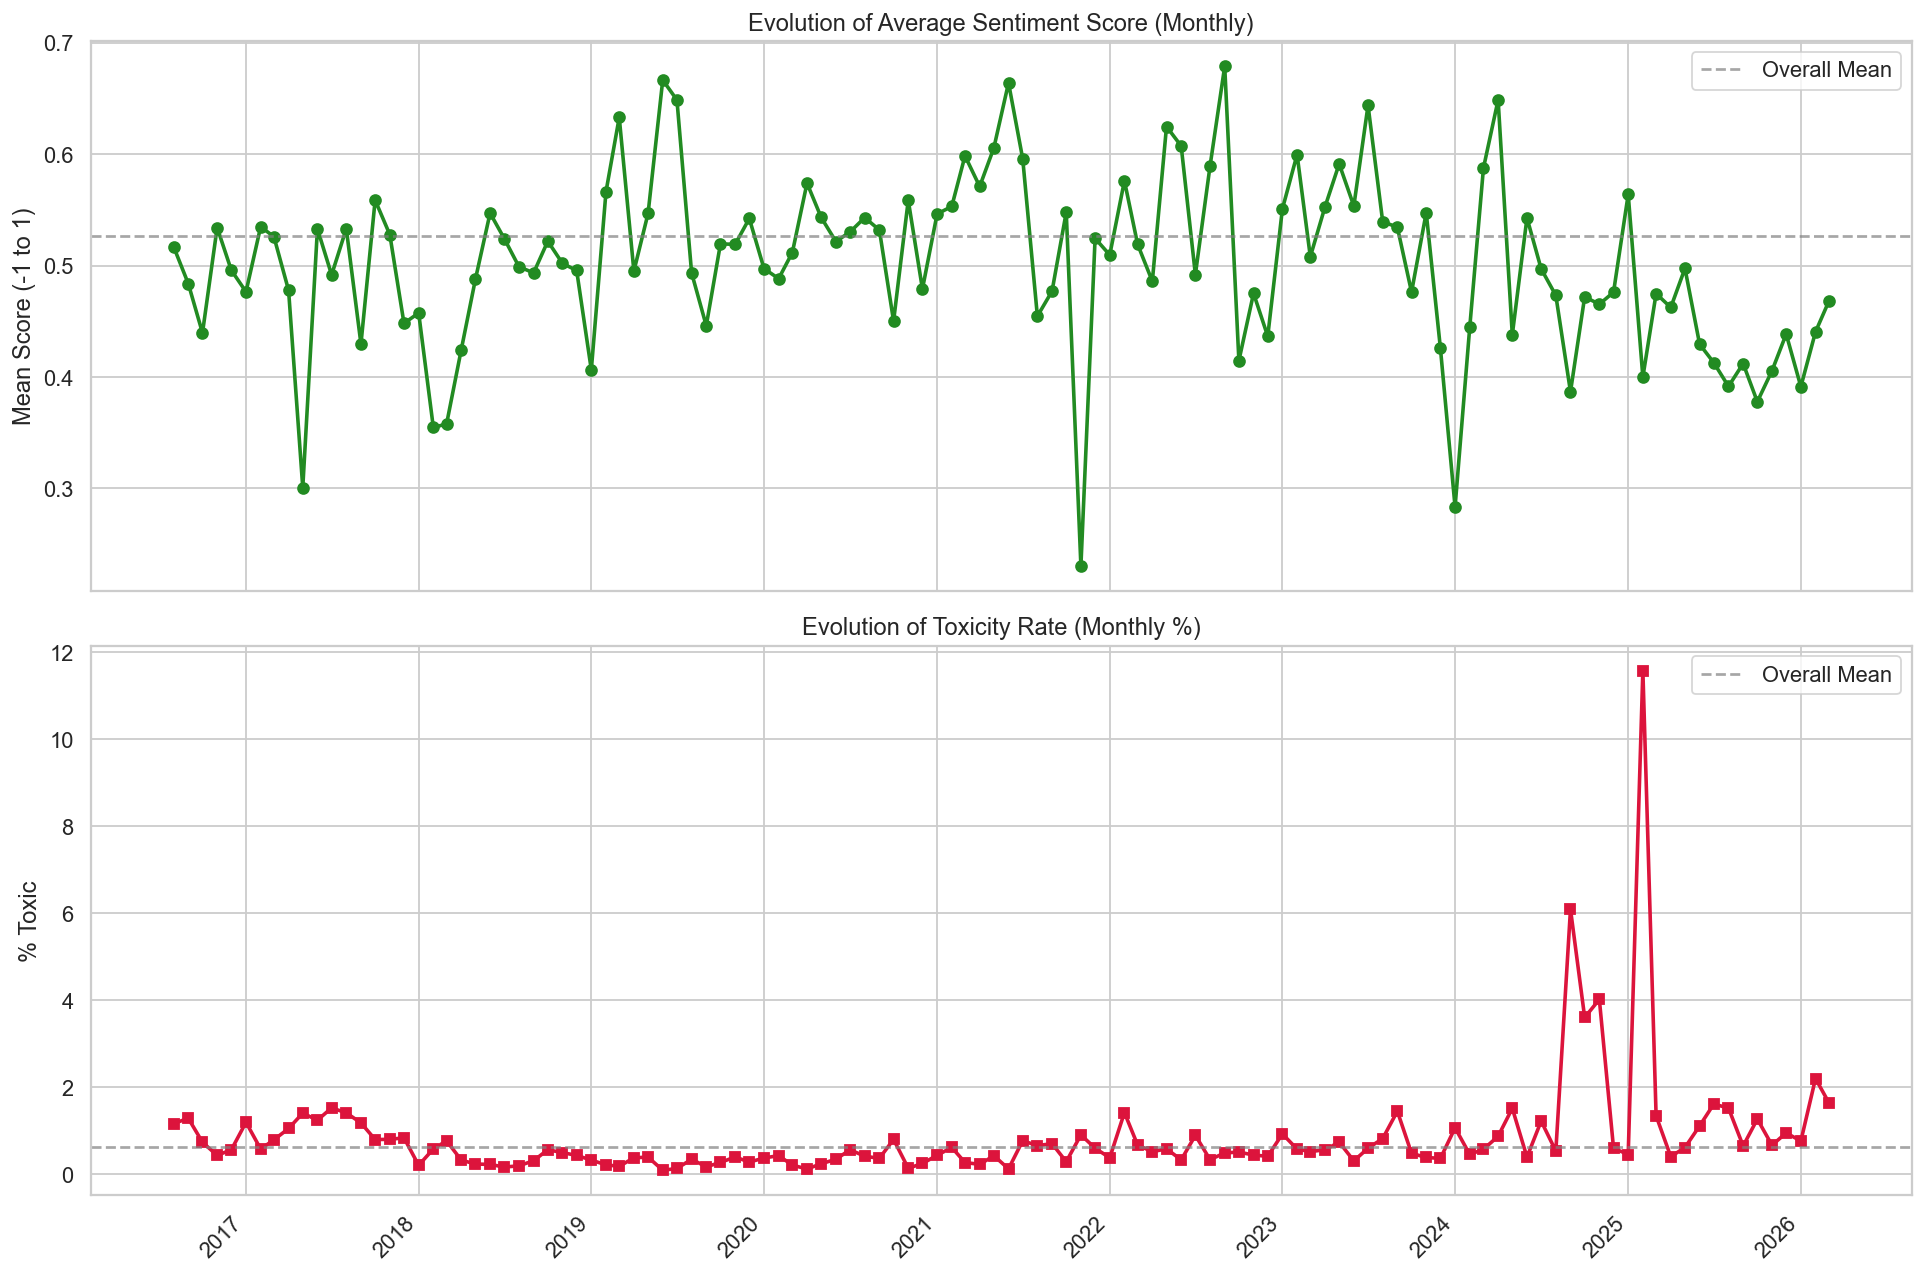

In [274]:
# 9.1 Evolution of average sentiment score and toxicity rate
evo = (
    df.groupby('month')
      .agg(avg_score=('sentiment_score', 'mean'),
           tox_rate=('is_toxic', 'mean'),
           n_comments=('comment_id', 'count'))
      .reset_index()
)
evo['tox_rate'] *= 100
# cast to str to guard against matplotlib UnitData objects in the month column
evo['month_dt'] = pd.to_datetime(evo['month'].astype(str), format='%Y-%m', errors='coerce')
evo = evo.sort_values('month_dt').dropna(subset=['month_dt'])

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top: Average Sentiment Score
axes[0].plot(evo['month_dt'].values, evo['avg_score'], marker='o', color='forestgreen', linewidth=2)
axes[0].set_title('Evolution of Average Sentiment Score (Monthly)')
axes[0].set_ylabel('Mean Score (-1 to 1)')
axes[0].axhline(df['sentiment_score'].mean(), ls='--', color='grey', alpha=0.7, label='Overall Mean')
axes[0].legend()

# Bottom: Toxicity Rate
axes[1].plot(evo['month_dt'].values, evo['tox_rate'], marker='s', color='crimson', linewidth=2)
axes[1].set_title('Evolution of Toxicity Rate (Monthly %)')
axes[1].set_ylabel('% Toxic')
axes[1].axhline(df['is_toxic'].mean()*100, ls='--', color='grey', alpha=0.7, label='Overall Mean')
axes[1].legend()

for ax_evo in axes:
    ax_evo.tick_params(axis='x', rotation=45)
    plt.setp(ax_evo.get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig(OUT / '09_sentiment_toxicity_evolution.png', dpi=300)
plt.savefig(OUT / '09_sentiment_toxicity_evolution.svg', dpi=300, transparent=True)  # --- IGNORE ---
plt.show()

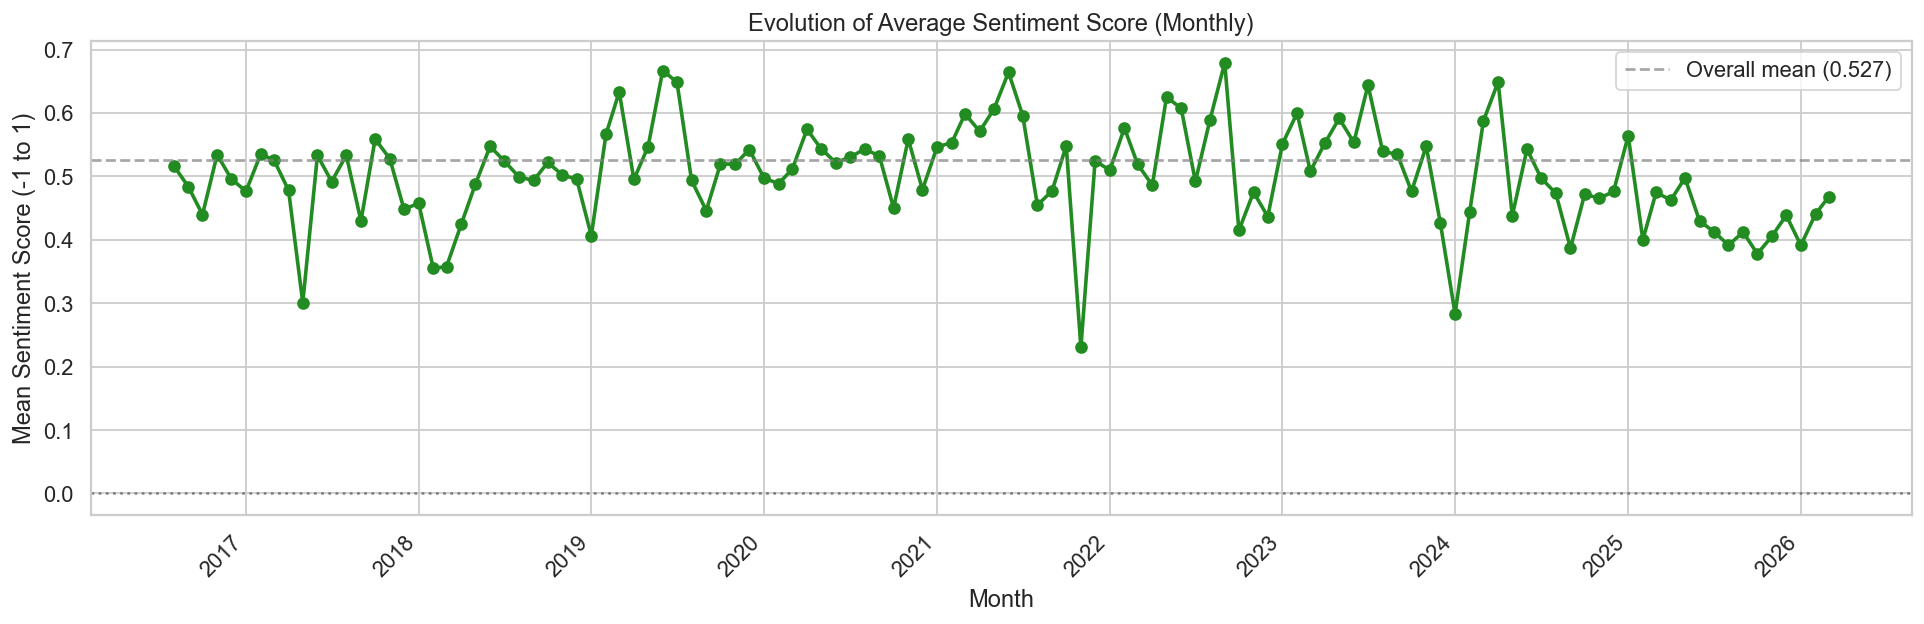

In [275]:
# 9.1b Average sentiment score evolution (monthly)
avg_evo = (
    df.groupby('month')['sentiment_score']
      .mean()
      .reset_index(name='avg_score')
)
avg_evo['month_dt'] = pd.to_datetime(avg_evo['month'].astype(str), format='%Y-%m', errors='coerce')
avg_evo = avg_evo.sort_values('month_dt').dropna(subset=['month_dt'])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(avg_evo['month_dt'].values, avg_evo['avg_score'].values,
        marker='o', color='forestgreen', linewidth=2)
_overall = df['sentiment_score'].mean()
ax.axhline(_overall, ls='--', color='grey', alpha=0.7, label=f'Overall mean ({_overall:.3f})')
ax.axhline(0, ls=':', color='black', alpha=0.4)
ax.set_title('Evolution of Average Sentiment Score (Monthly)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Sentiment Score (-1 to 1)')
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / '09b_avg_sentiment_evolution.png', dpi=300)
plt.savefig(OUT / '09b_avg_sentiment_evolution.svg', dpi=300, transparent=True)
plt.show()


---
## 10. Summary & Key Findings

In [276]:
def _top(series):
    vc = series.value_counts()
    return vc.index[0] if len(vc) else 'N/A'

print('=== KEY FINDINGS SUMMARY ===')
lines = [
    f"Dataset: {len(df):,} comments across {df['media_id'].nunique():,} posts, {df['author_id'].nunique():,} unique users",
    "",
    "SENTIMENT",
    f"  Overall negative rate : {df['is_negative'].mean():.1%}",
    f"  Overall toxicity rate : {df['is_toxic'].mean():.2%}",
    "",
    f"TOP NEGATIVE EMOTION   : {_top(neg['emotion'])}",
    f"TOP NEGATIVE INTENT    : {_top(neg['intent'])}",
    f"TOP TOXIC EMOTION      : {_top(tox['emotion'])}",
    f"TOP TOXIC INTENT       : {_top(tox['intent'])}",
]
if df['persona_codename'].notna().any():
    pa = df.dropna(subset=['persona_codename']).groupby('persona_codename').agg(
        neg=('is_negative','mean'), tox=('is_toxic','mean'))
    lines += [
        "",
        f"PERSONA highest negative rate : {pa['neg'].idxmax()} ({pa['neg'].max():.1%})",
        f"PERSONA highest toxicity rate : {pa['tox'].idxmax()} ({pa['tox'].max():.1%})",
    ]
if df['rfm_cluster_name'].notna().any():
    ra = df.dropna(subset=['rfm_cluster_name']).groupby('rfm_cluster_name').agg(
        neg=('is_negative','mean'), tox=('is_toxic','mean'))
    lines += [
        f"RFM cluster highest negative  : {ra['neg'].idxmax()} ({ra['neg'].max():.1%})",
        f"RFM cluster highest toxicity  : {ra['tox'].idxmax()} ({ra['tox'].max():.1%})",
    ]
print(chr(10).join(lines))


=== KEY FINDINGS SUMMARY ===
Dataset: 487,604 comments across 1,501 posts, 191,096 unique users

SENTIMENT
  Overall negative rate : 5.0%
  Overall toxicity rate : 0.63%

TOP NEGATIVE EMOTION   : sadness
TOP NEGATIVE INTENT    : criticism
TOP TOXIC EMOTION      : anger
TOP TOXIC INTENT       : criticism

PERSONA highest negative rate : THE_HATER (52.0%)
PERSONA highest toxicity rate : THE_HATER (65.3%)
RFM cluster highest negative  : Passive regulars (4.9%)
RFM cluster highest toxicity  : Occasional Visitors (0.6%)
